# **AI: Machine Learning**

<img src="https://emojigraph.org/media/apple/robot_1f916.png" alt="logo" width="128">


## **Jason Monroe**

<p> ✉️ <a href="mailto:jason@jasonmonroe.com?subject=GitHub Machine Learning Credit Card Users Churn Prediction">jason@jasonmonroe.com</a></p>

<p>📅 October 28, 2024</p>


<p>🗂️ credit_card_churn_predictor_notebook.html</p>

---

# **Credit Card Users Churn Prediction**


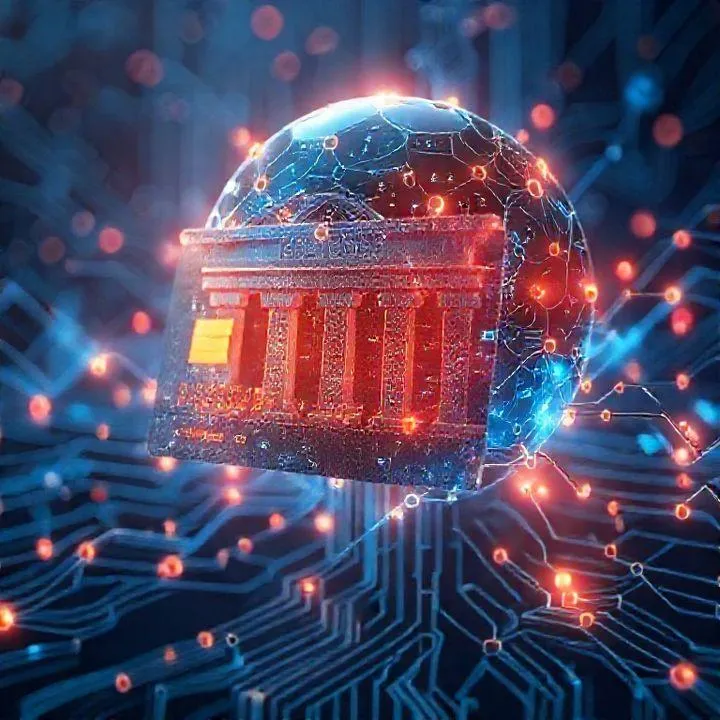

## Problem Statement

### ⚙️ Project Overview

As a **machine learning engineer** working with thera bank, this project aims to address a critical business problem: the recent **steep decline in credit card user retention**. credit cards are a vital revenue stream for the bank through various fees (annual, balance\_transfer, late\_payment, etc.). customer attrition in this segment directly impacts the bank's profitability.

the core objective is to develop a robust **classification model** that can **identify customers highly likely to renounce their credit card services (attrite)** and, crucially, help infer the **key reasons** driving this attrition. the insights gained will directly inform the bank's strategy to improve services and retention.

---

### 📊 Data Description

the dataset provides a comprehensive snapshot of customer demographics, account characteristics, and usage behavior. the target variable is `attrition_flag`.

| Variable Name | Description | key\_concept |
| :--- | :--- | :--- |
| **client_num** | unique identifier for the customer/account. | *identifier* |
| **attrition\_flag** | **target variable**: "attrited customer" (closed account) or "existing customer". | *categorical (target)* |
| **customer\_age** | age in years. | *demographic* |
| **gender** | gender of the account holder. | *demographic* |
| **dependent\_count** | number of dependents. | *demographic* |
| **education\_level** | educational qualification (e.g., graduate, high school, doctorate). | *demographic* |
| **marital\_status** | marital status of the account holder. | *demographic* |
| **income\_category** | annual income category of the account holder. | *demographic/financial* |
| **card\_category** | type of credit card. | *account feature* |
| **months\_on\_book** | tenure: period of relationship with the bank (in months). | *account feature* |
| **total\_relationship\_count** | total no. of products (e.g., loans, savings accounts) held by the customer. | *account feature* |
| **months\_inactive\_12\_mon** | no. of months inactive in the last 12 months. | *usage behavior* |
| **contacts\_count\_12\_mon** | no. of contacts initiated by the customer/bank in the last 12 months. | *usage behavior* |
| **credit\_limit** | maximum credit limit on the card. | *financial metric* |
| **total\_revolving\_bal** | the **unpaid portion** of the revolving credit account that carries over to the next month. | *financial metric* |
| **avg\_open\_to\_buy** | the **average amount of available credit** over the last 12 months. | *financial metric* |
| **total\_amt\_chng\_q4\_q1** | ratio of transaction amount in q4 vs q1. | *usage trend* |
| **total\_trans\_amt** | total transaction amount over the last 12 months. | *usage metric* |
| **total\_trans\_ct** | total transaction count over the last 12 months. | *usage metric* |
| **total\_ct\_chng\_q4\_q1** | ratio of transaction count in q4 vs q1. | *usage trend* |
| **avg\_utilization\_ratio** | the average percentage of **available credit used** by the customer. | *financial metric* |

---

### 💡 Key Financial Metrics Relationships

the following metrics are interconnected and crucial for understanding a customer's credit card usage profile:

* **total\_revolving\_bal:** the portion of the credit card balance that is **not paid in full** each month and rolls over.
* **avg\_open\_to\_buy (otb):** represents the **unused portion** of the credit limit, averaged over the last 12 months.
* **avg\_utilization\_ratio (u-ratio):** represents the average percentage of the credit limit that the customer has **used**.

these three are mathematically linked by the relationship:
$$
\frac{avg\_open\_to\_buy}{credit\_limit} + avg\_utilization\_ratio \approx 1
$$
this relationship shows that the unused credit (normalized by limit) plus the used credit (u-ratio) should sum close to one (100% of the limit).

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.


**Note:** *The code above is to fix warning of libraries that will be declared below.*

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imblearn==0.12.0 xgboost==2.0.3 -q --user
# !pip install --upgrade -q threadpoolctl

In [1]:
!pip install scikit-learn seaborn matplotlib numpy pandas imbalanced-learn xgboost category_encoders threadpoolctl -q

In [2]:
# ==================================
#  IMPORT LIBRARIES
# ==================================

# Standard libraries
import os
import time

## 🛠️ Vendor/Specialized Libraries

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import category_encoders as ce

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    make_scorer
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validation_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
import warnings  # To suppress warnings
warnings.filterwarnings("ignore")

In [4]:
os.environ['PATH'] += ':/root/.local/bin'

# To define maximum number of columns to be displayed in a dataframe
pd.set_option('display.max_columns', None)

# To supress scientific notations for a dataframe
pd.set_option('display.float_format', lambda x: "%.3f" % x)

# To suppress scientific notations (Duplicate, but included for completeness)
pd.set_option('display.float_format', lambda x: "%.3f" % x)

In [5]:
# ==================================
#  CONSTANTS
# ==================================
FILE_NAME = 'sample_data.csv'
SOURCE_PATH = ''
CSV_FILE = SOURCE_PATH + FILE_NAME

# Specifies the number of base estimators (individual models) that will be trained
# and combined to form the final ensemble model.
BASE_ESTIMATOR_CNT = 100

# Number of folds to use in K-Fold Cross-Validation.
CV_FOLDS = 5

# Sample Data Split
DATA_TEMP_SPLIT = 0.3
DATA_TRAINING_SPLIT = 0.7
DATA_TESTING_SPLIT = 0.15
DATA_VALIDATION_SPLIT = 0.15
HALF_SPLIT = 0.5

# Number of features to consider when looking for the best split at each node of
# the individual decision trees built within the boosting process.
FEATURES_SPLIT_PCT = 0.5 # baseline for randomness (50%)

# In a Google Colab environment, n_jobs=-1 will use all cores allocated to your
# session, which usually means 2 or more cores, significantly accelerating the
# hyperparameter search compared to the default n_jobs=1 (which uses only one core).
MAX_PROC_THREADS = -1

# Specifies the minimum loss reduction required to make a further partition
# (split) on a leaf node of the tree.
MIN_TREE_SPLIT = 1
MSEC = 1000

# Controls the maximum number of levels (nodes) allowed in each individual decision
# tree within the forest.
NODE_RFC_CNT = 4
NODE_XGBC_CNT = 3

# Number of different parameter combinations that will be tried.
PARAM_DISTR_CNT = 10
PERCENTILE = 100
SECS_IN_MIN = 60
SEED = 42

# Hyperparameter that controls the fraction of the training samples used to train
# each individual tree.
# Sample size of training data for Stochastic Gradient Boosting (SGB).
# Increased robustness, lower variance, generally better generalization.
SUB_SAMPLE_SIZE = 0.7

# Tuning parameters
TUNED_ESTIMATOR_CNT = 20
TUNED_LEARNING_RATE = 0.1
UNTUNED_ESTIMATOR_CNT = 50
UNTUNED_LEARNING_RATE = 0.05

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again*.

## Loading the dataset

In [6]:
# Load data
data = pd.read_csv(CSV_FILE)

# Create a copy of the data (that will be used later)
df = data.copy()

## Data Overview

- Observations
- Sanity checks

In [7]:
# Let's view the first 5 rows of the data
data.head()

,client_num,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000


In [8]:
# Let's view the last 5 rows of the data
data.tail()

,client_num,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.000,1851,2152.000,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,NaN,Divorced,$40K - $60K,Blue,25,4,2,3,4277.000,2186,2091.000,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.000,0,5409.000,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,NaN,$40K - $60K,Blue,36,4,3,3,5281.000,0,5281.000,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.000,1961,8427.000,0.703,10294,61,0.649,0.189


In [9]:
# Checking the number of rows and columns in the data
data.shape

(10127, 21)

In [10]:
# Checking datatyapes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_num                10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           8608 non-null   object 
 6   marital_status            9378 non-null   object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [11]:
# Description of data based on percentile.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
client_num,10127.000,739177606.334,36903783.450,708082083.000,713036770.500,717926358.000,773143533.000,828343083.000
customer_age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
total_relationship_count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
months_inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
contacts_count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
credit_limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
total_revolving_bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
avg_open_to_buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000


In [12]:
# Display only missing values
df.isnull().sum()[df.isnull().sum() > 0]

,0
education_level,1519
marital_status,749


In [13]:
# Remove "N/A" from Education Level, "NaN" from Marital Status and "abc" from Income Category
df['education_level'] = df['education_level'].replace('N/A', np.nan)
df['marital_status'] = df['marital_status'].replace('NaN', np.nan)
df['income_category'] = df['income_category'].replace('abc', np.nan)

In [14]:
print(FILE_NAME + ' has ' + str(df.shape[0]) + ' rows and ' + str(df.shape[1]) + ' columns.')

sample_data.csv has 10127 rows and 21 columns.


In [15]:
# Checking the percentages of classes in the target variable column.
df['attrition_flag'].value_counts(1) * PERCENTILE

,proportion
attrition_flag,
Existing Customer,83.934
Attrited Customer,16.066


Another observation is that almost 84% of the customers are existing while 16% are no longer customers.

**Observations**

1.  Youngest customer is 26 years old.  Not to sound cynical but wouldn't you want to have younger customers if you want to earn revenue as a company by collecting more fees?
2.  There's a larger gap (21 years) between the majority of the customers age (52) and the oldest customer (73).  This shows us that the customer base is right skewed as there are fewer customers older than 52.
3.  Most customers have at least one dependent.
4. No customer has been with this bank for more than 5 years.
5.  The total number of products held by customers is evenly distributed.
6. Most of the customers have balances over 1000 and
carry a balance of at least $1,000 that's rolling over.
7. The average transaction amount is close to the 75% tile which means that it's negatively skewed towards the bottom.
8. The average customer utilization ratio is slightly above have the customer base.
9. The most transactions by a customer is significant higher than the bottom 75% which indicates there are a few high rollers that frequent this establishment.

**Sanity Checks**


1.   For the most part the data looks evenly distrubited.
2.   There are at least 10,000 rows of data to perfect the UI storage?
3. We're missing data from customer's marital status and education level that needs to be treated.
4. Income Category has the value "abc" that doesn't make any statistical sense.





## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. How is the total transaction amount distributed?
2. What is the distribution of the level of education of customers?
3. What is the distribution of the level of income of customers?
4. How does the change in transaction amount between Q4 and Q1 (`total_ct_change_Q4_Q1`) vary by the customer's account status (`Attrition_Flag`)?
5. How does the number of months a customer was inactive in the last 12 months (`Months_Inactive_12_mon`) vary by the customer's account status (`Attrition_Flag`)?
6. What are the attributes that have a strong correlation with each other?



#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [16]:
# How is the total transaction amount distributed?
trans_amt_dist = df['total_trans_amt'].describe().T

print('Distribution of total transaction amount:')
for key, value in trans_amt_dist.items():
    print(f"{key} is {value}")

Distribution of total transaction amount:
count is 10127.0
mean is 4404.086303939963
std is 3397.129253557085
min is 510.0
25% is 2155.5
50% is 3899.0
75% is 4741.0
max is 18484.0


Total transaction amount is right skewed.

In [17]:
# ==================================
#  HELPER FUNCTIONS
# ==================================

def start_timer() -> float:
    """
    Start a timer
    """
    return time.time()


def get_time(start_time_float: float) -> str:
    diff = abs(time.time() - start_time_float)
    hours, remainder = divmod(diff, SECS_IN_MIN*SECS_IN_MIN)
    minutes, seconds = divmod(remainder, SECS_IN_MIN)
    fractional_seconds = seconds - int(seconds)

    ms = fractional_seconds * MSEC
    return f"{int(minutes)}m {int(seconds)}s {int(ms)}ms"


def show_timer(start_time_int: float) -> None:
    print(f"Run Time: {get_time(start_time_int)}")


def show_banner(title: str, section: str='') -> None:
    PADDING = 2
    strlen = len(title) + PADDING

    # Top line
    #print("\n")
    print('# ', end='')
    print('=' * strlen)
    print('#', end='')

    # Show title
    print('  ' + title)

    print('# ', end='')
    print('=' * strlen)
    print('')
    #print('# ', end='')

    # Show section
    if section:
        print(' ' + section)
        print("\n")

In [18]:
# function to plot a boxplot and a histogram along the same scale.
def histogram_boxplot(data: pd.DataFrame, feature: str, chart_title: str='', figsize:tuple=(12, 7), kde:bool=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots

    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column

    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram

    # Set Histogram Title
    chart_title_str = feature.title().replace('_', ' ')
    plt.xlabel(chart_title_str)

    if chart_title:
        chart_title_str = chart_title.title().replace('_', ' ')
        #plt.title(chart_title.title() + 'Histogram')

    plt.title(chart_title_str + ' Histogram')


    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram

    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [19]:
# function to create labeled barplots
def labeled_barplot(chart_data: pd.DataFrame, feature: str, chart_title: str='', perc:bool=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(chart_data[feature])  # length of the column
    count = chart_data[feature].nunique()

    if n is None:
        plt.figure(figsize=(count + 1, 5))

    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=chart_data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                PERCENTILE * (p.get_height() / total)
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    if chart_title:
        plt.title(chart_title)

    plt.xlabel(feature.title().replace('_', ' '))
    #plt.ylabel("Income Range")
    plt.show()  # show the plot

In [20]:
# Function to plot stacked bar chart
def stacked_barplot(data: pd.DataFrame, predictor: str, target: str):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter,
        ascending=False
    )

    print(tab1)
    print('\n')

    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter,
        ascending=False
    )

    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )

    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [21]:
### Function to plot distributions
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Data Pre-processing

In [22]:
# What is the distribution of the level of education of customers?
edu_level_dist = df['education_level'].value_counts()
sum_val = edu_level_dist.sum()

show_banner('Distribution of education level')
for key, value in edu_level_dist.items():
    pct = round((value / sum_val) * PERCENTILE)
    print(f"{key} is {value} or {pct}%")

# =================================
#  Distribution of education level
# =================================

Graduate is 3128 or 36%
High School is 2013 or 23%
Uneducated is 1487 or 17%
College is 1013 or 12%
Post-Graduate is 516 or 6%
Doctorate is 451 or 5%


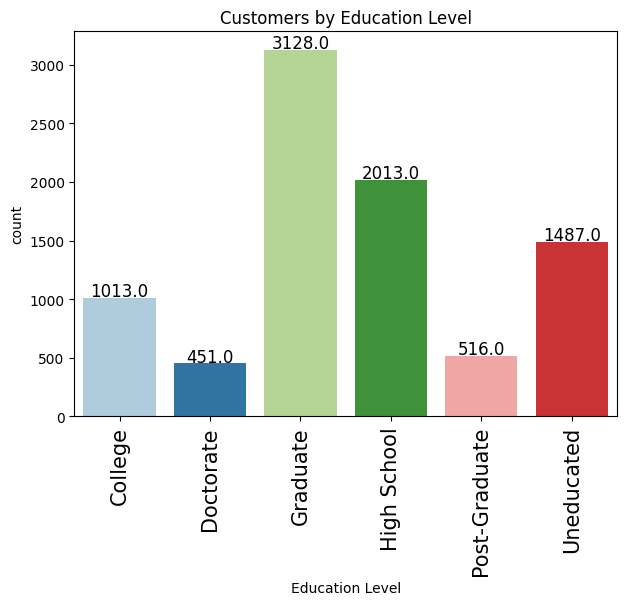

In [23]:
# Display box plot
labeled_barplot(df, 'education_level', 'Customers by Education Level')

In [24]:
# What is the distribution of the level of income of customers?

income_dist = df['income_category'].value_counts()
sum_val = income_dist.sum()

show_banner('Distribution of income level')

for key, value in income_dist.items():
  pct = round((value / sum_val) * PERCENTILE)
  print(f"{key} is {value} or {pct}%")

# ==============================
#  Distribution of income level
# ==============================

Less than $40K is 3561 or 40%
$40K - $60K is 1790 or 20%
$80K - $120K is 1535 or 17%
$60K - $80K is 1402 or 16%
$120K + is 727 or 8%


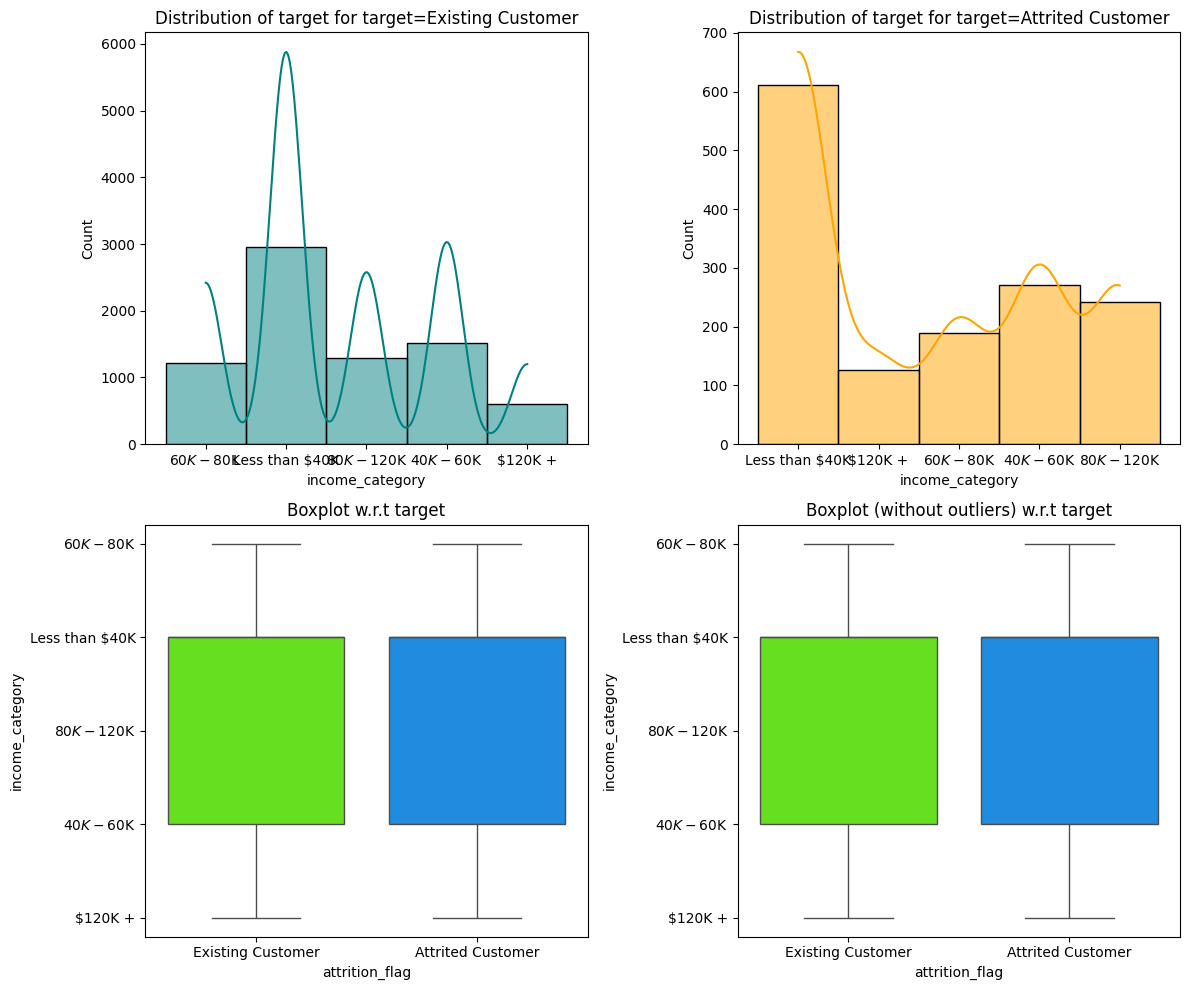

In [25]:
distribution_plot_wrt_target(df, 'income_category', 'attrition_flag')

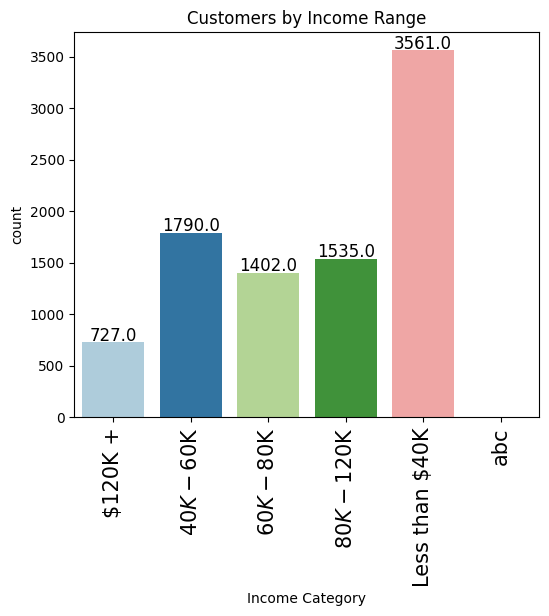

In [26]:
# Display labeled bar plot
labeled_barplot(df, 'income_category', 'Customers by Income Range')

In [27]:
# How does the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer's account status (Attrition_Flag)?
change_data = df.groupby(['attrition_flag'])['total_ct_chng_q4_q1'].describe()

change_data

,count,mean,std,min,25%,50%,75%,max
attrition_flag,,,,,,,,
Attrited Customer,1627.000,0.554,0.227,0.000,0.400,0.531,0.692,2.500
Existing Customer,8500.000,0.742,0.228,0.028,0.617,0.721,0.833,3.714


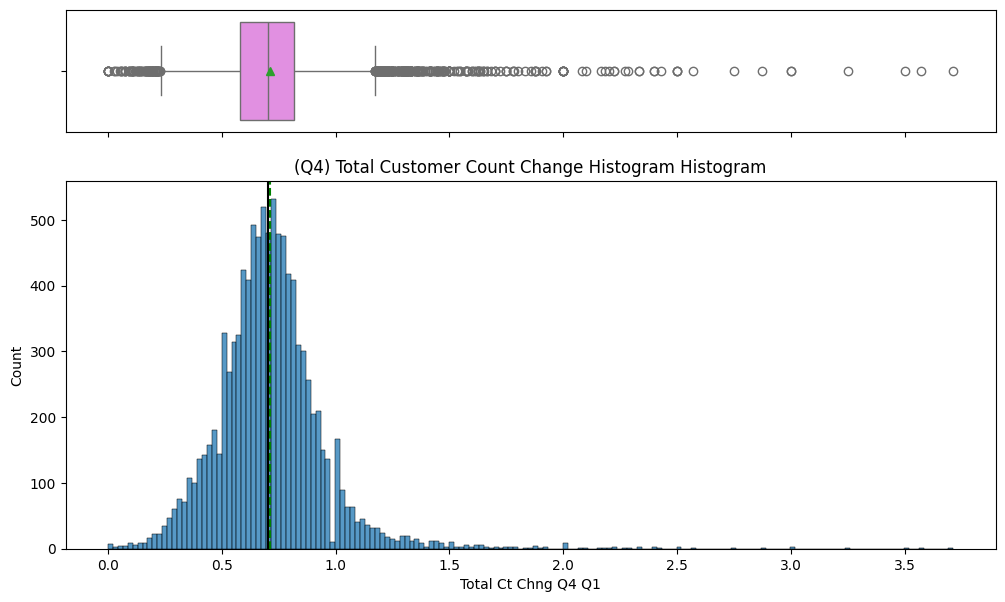

In [28]:
# Display box plot
histogram_boxplot(df, 'total_ct_chng_q4_q1', '(Q4) Total Customer Count Change Histogram')

The Attrited customers is lower than existing customers with respect to transaction amount.  This makes sense as a former customer would likely not utilize the bank for banking services.

In [29]:
# How does the number of months a customer was inactive in the last 12 months (Months_Inactive_12_mon) vary by the customer's account status (Attrition_Flag)?
inactive_data = df.groupby('attrition_flag')['months_inactive_12_mon'].describe()

In [30]:
show_banner('Inactive Data')
inactive_data

# ===============
#  Inactive Data
# ===============



,count,mean,std,min,25%,50%,75%,max
attrition_flag,,,,,,,,
Attrited Customer,1627.000,2.693,0.900,0.000,2.000,3.000,3.000,6.000
Existing Customer,8500.000,2.274,1.017,0.000,1.000,2.000,3.000,6.000


Customers that have not been active for over 12 months.

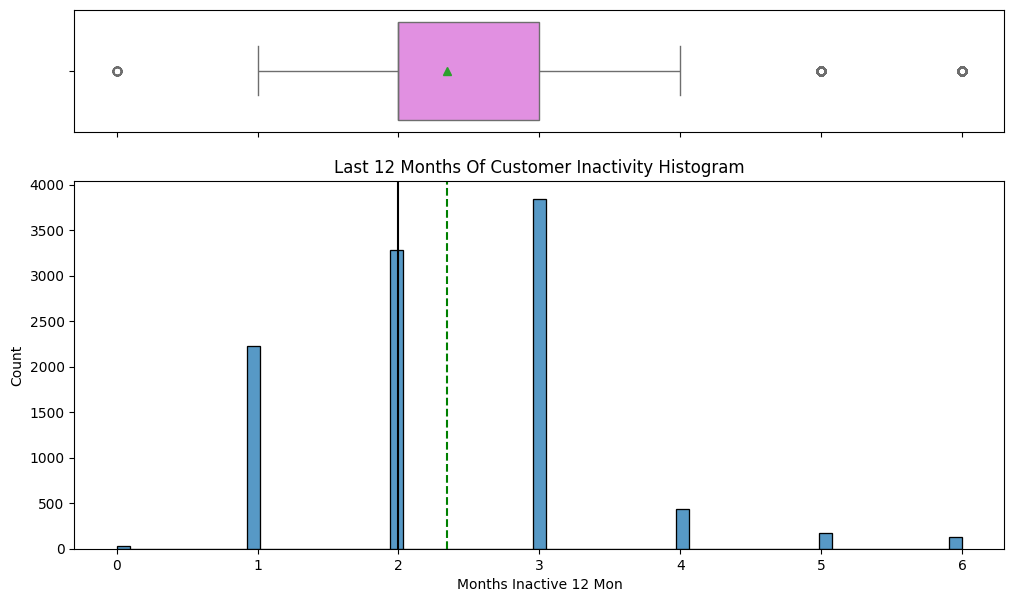

In [31]:
histogram_boxplot(df, 'months_inactive_12_mon', 'Last 12 months of customer inactivity')

Customers that have left the bank have a 50% chance of returning as a customer.

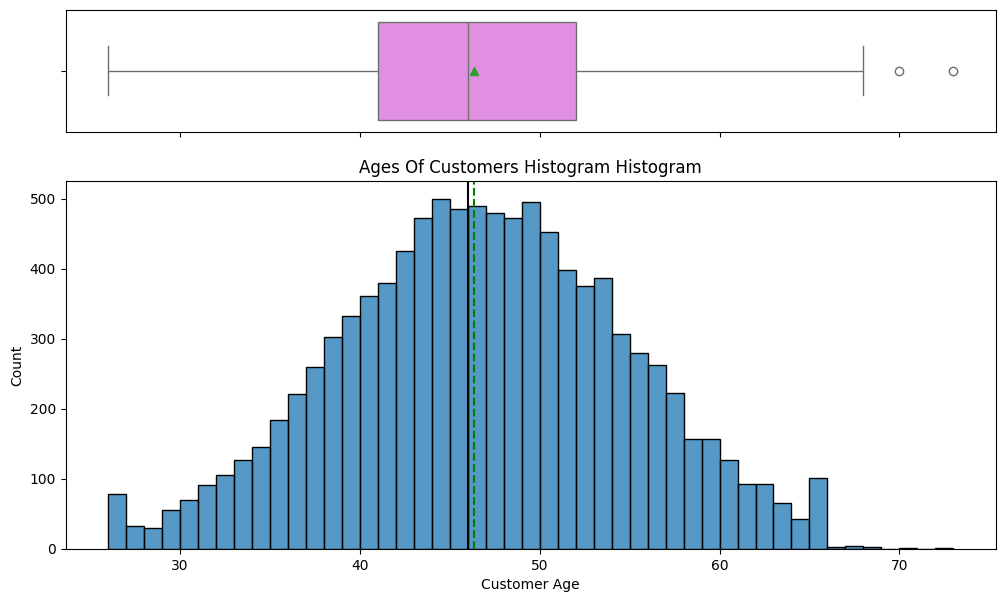

In [32]:
histogram_boxplot(df, 'customer_age', 'Ages of Customers Histogram')

Customers age are most likely to be in the mid to late 40s.

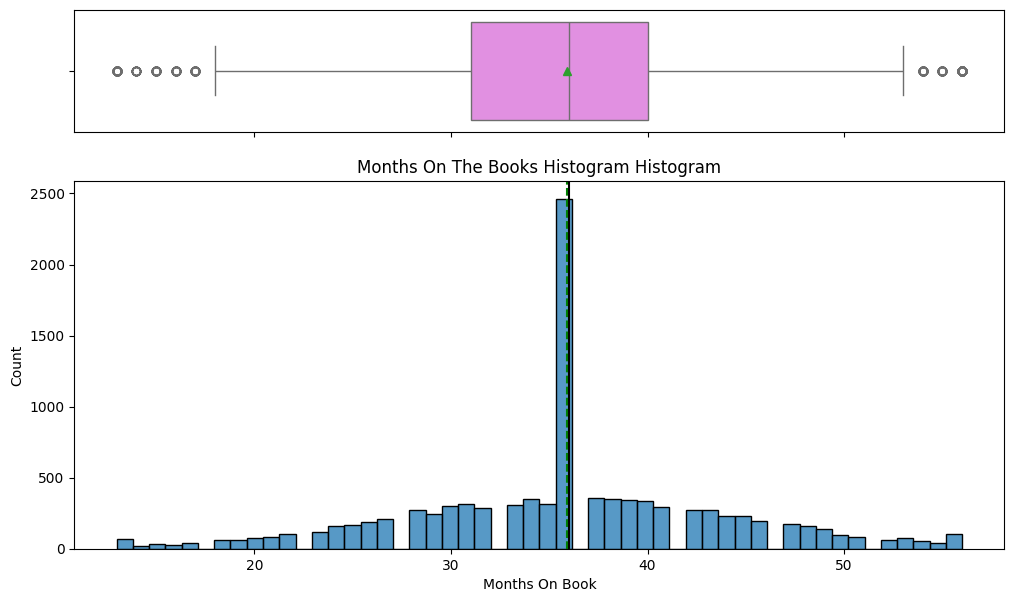

In [33]:
histogram_boxplot(df, 'months_on_book', 'Months on the books Histogram')

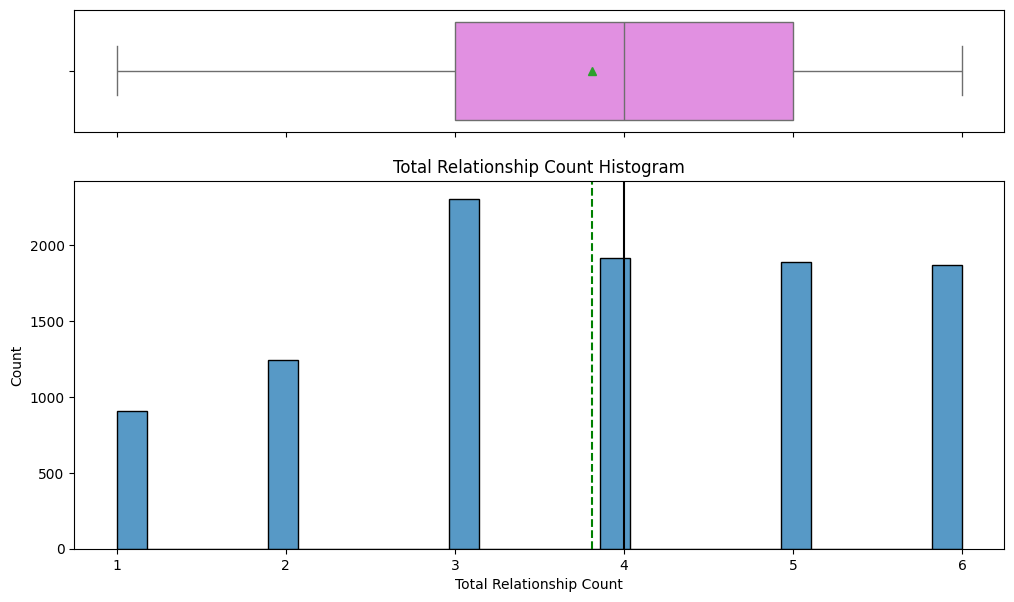

In [34]:
histogram_boxplot(df, 'total_relationship_count')

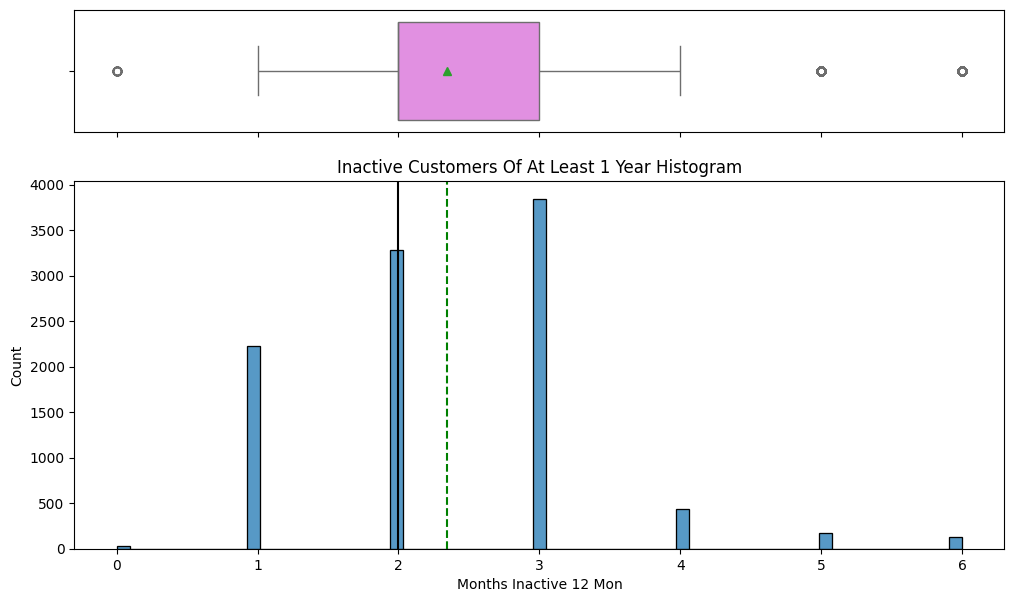

In [35]:
histogram_boxplot(df, 'months_inactive_12_mon', 'Inactive customers of at least 1 year')

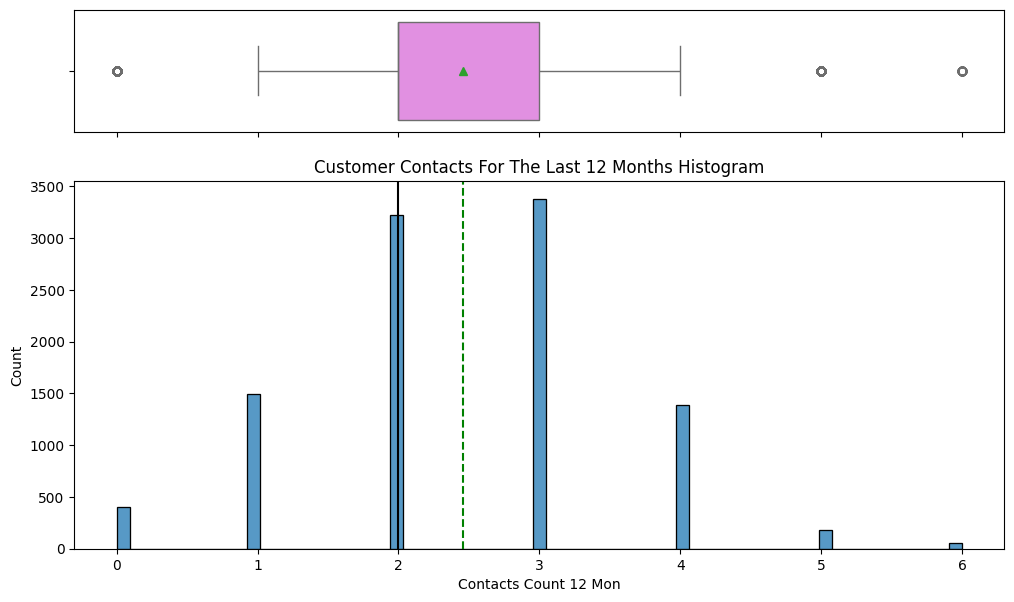

In [36]:
histogram_boxplot(df, 'contacts_count_12_mon', 'Customer contacts for the last 12 months')

In [37]:
# Count the number of contacts by highest frequency
df['contacts_count_12_mon'].value_counts(1).sort_values(ascending=False)

,proportion
contacts_count_12_mon,
3,0.334
2,0.319
1,0.148
4,0.137
0,0.039
5,0.017
6,0.005



*   33.4% have been in contact in the last 12 months.
*   31.9% have been in contact in the last 12 months.
*   14.8% have been in contact in the last 12 months.
*   13.7% have been in contact in the last 12 months.
*   3.9% have been in contact in the last 12 months.



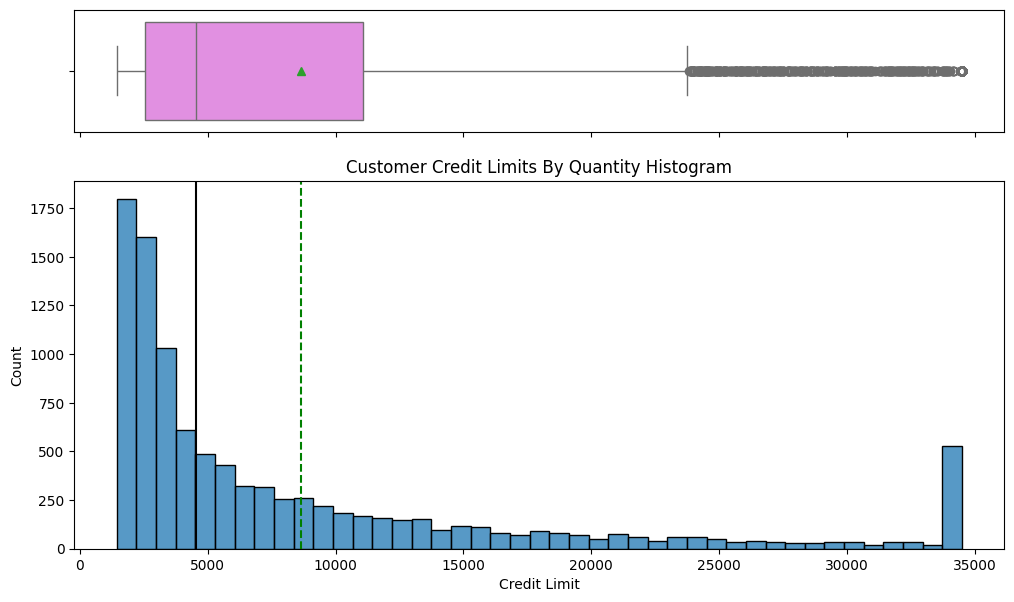

In [38]:
histogram_boxplot(df, 'credit_limit', 'Customer Credit Limits by Quantity')

Credit limit is right skewed w/ outliers.

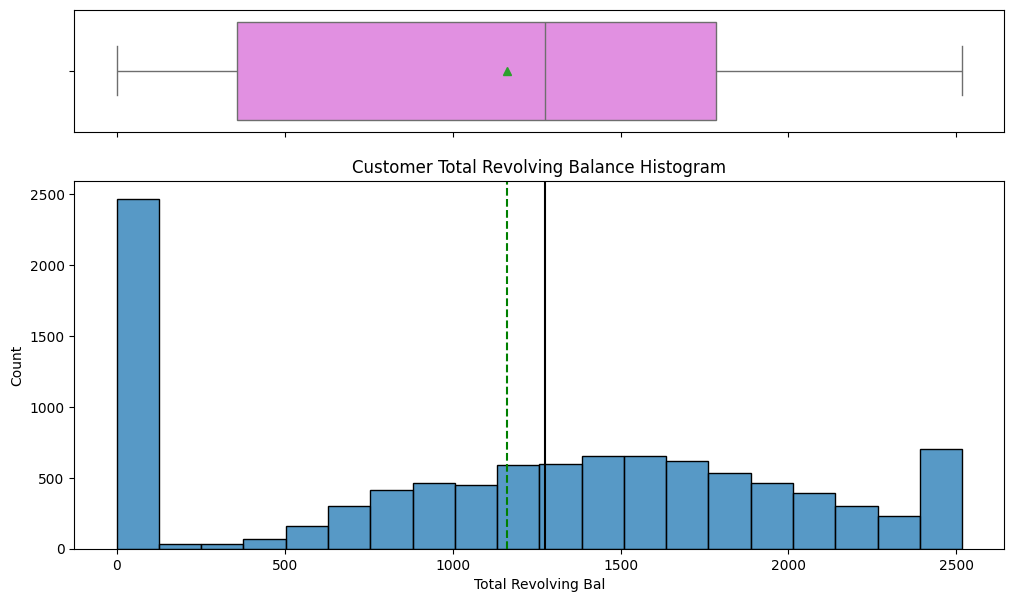

In [39]:
histogram_boxplot(df, 'total_revolving_bal', 'Customer Total Revolving Balance')

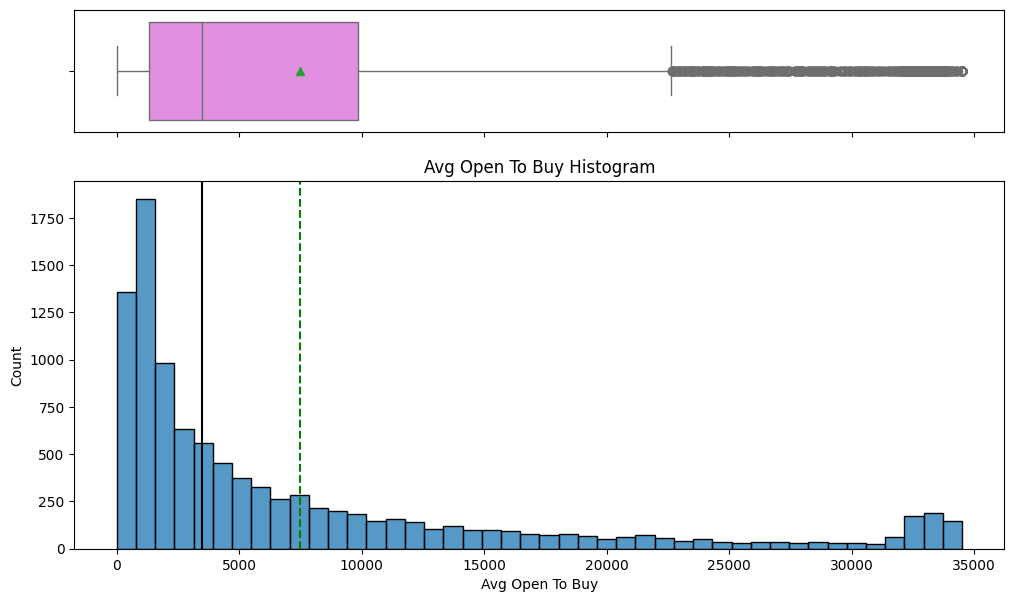

In [40]:
histogram_boxplot(df, 'avg_open_to_buy')

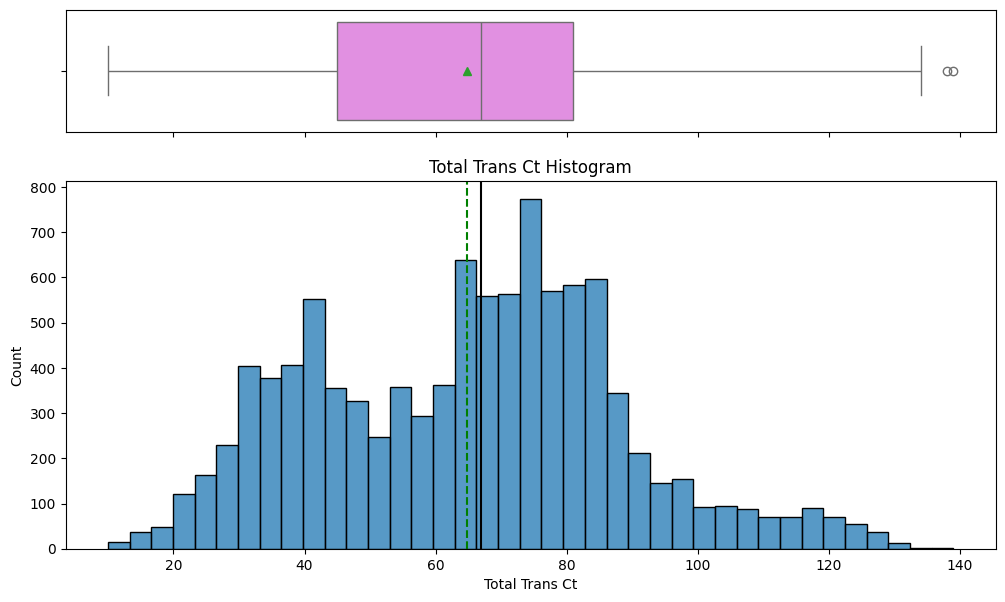

In [41]:
histogram_boxplot(df, 'total_trans_ct')

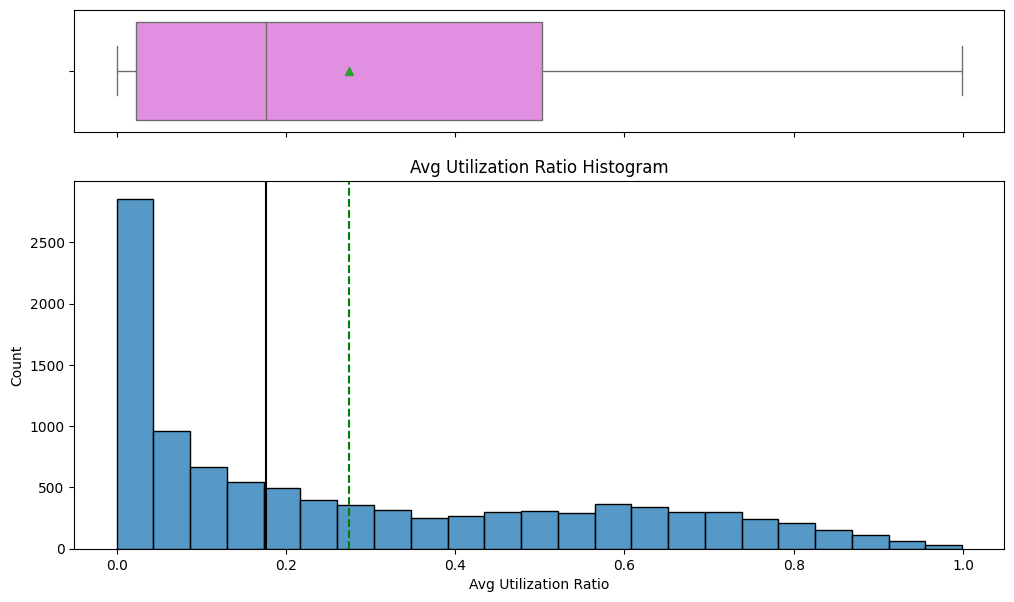

In [42]:
histogram_boxplot(df, 'avg_utilization_ratio')

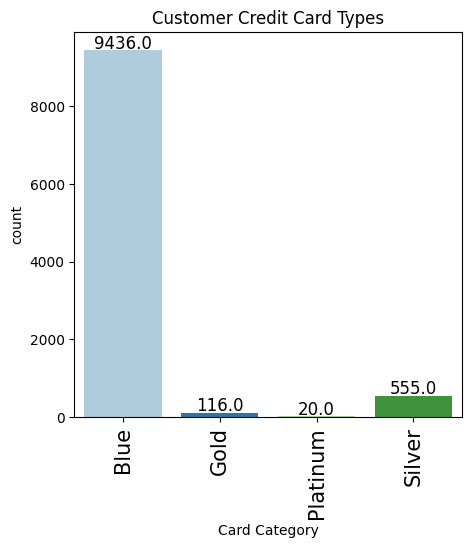

In [43]:
labeled_barplot(df, 'card_category', 'Customer Credit Card Types')

Most customers have a blue card.

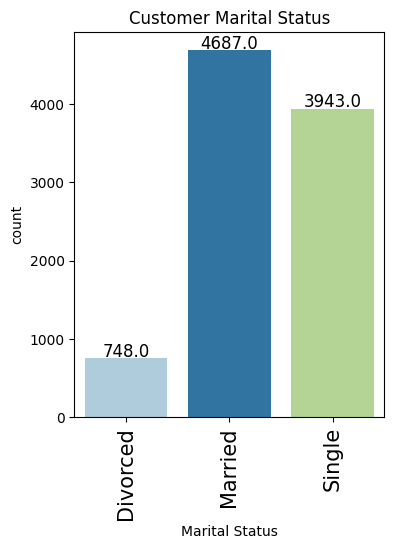

In [44]:
labeled_barplot(df, 'marital_status', 'Customer Marital Status')

Married people are more likely to be customers.

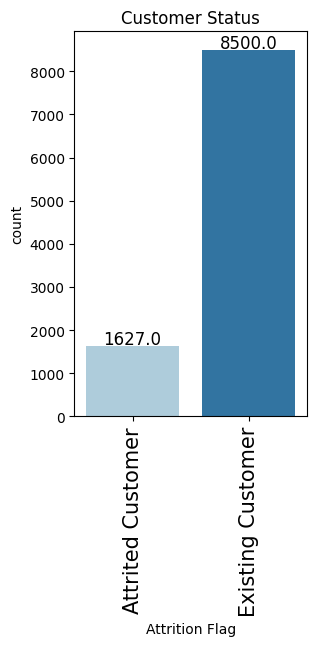

In [45]:
labeled_barplot(df, 'attrition_flag', 'Customer Status')

As stated before most customers are continuing to use this bank as a source of business.

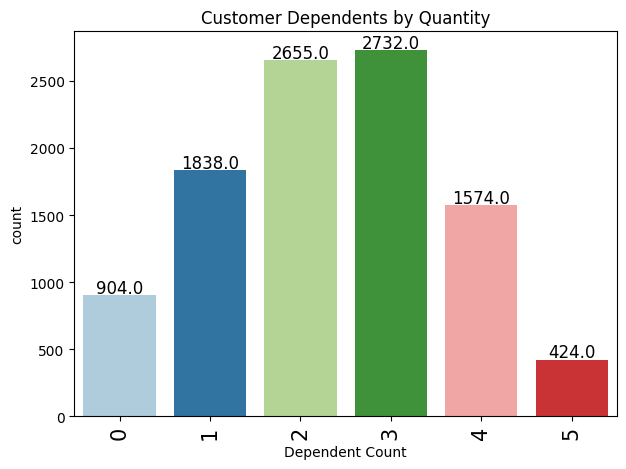

In [46]:
labeled_barplot(df, 'dependent_count', 'Customer Dependents by Quantity')

In [47]:
df['dependent_count'].value_counts(1).sort_values(ascending=False)

,proportion
dependent_count,
3,0.270
2,0.262
1,0.181
4,0.155
0,0.089
5,0.042


With respect fo dependents:


*   27% have 3 dependents.
*   26.2% have 2 dependents.
*   18.1 % have 1 dependent.
*   15.5% have 4 dependents.
*   8.9% have NO dependents.
*.  4.2% have 5 dependents.



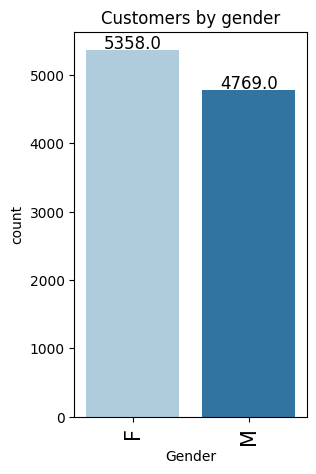

In [48]:
labeled_barplot(df, 'gender', 'Customers by gender')

There are more female customers than men.

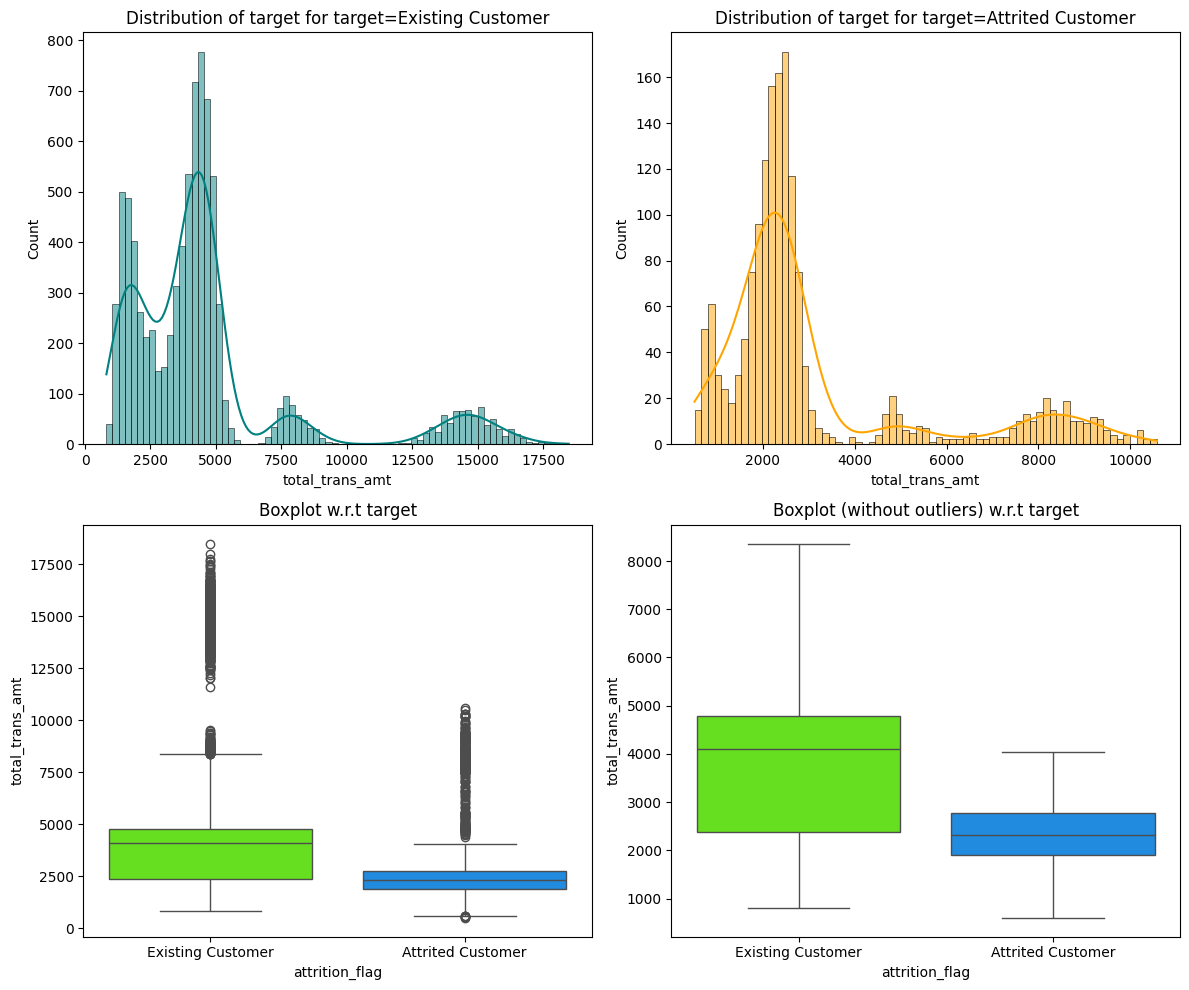

In [49]:
distribution_plot_wrt_target(df, 'total_trans_amt', 'attrition_flag')


*   Total transaction amount is not that much different between existing customers and former customers.
*   The median total transaction amount is 4000 for existing customers, while former customers amount is around 2500.
*   The IQR is much smaller for attrited customers.

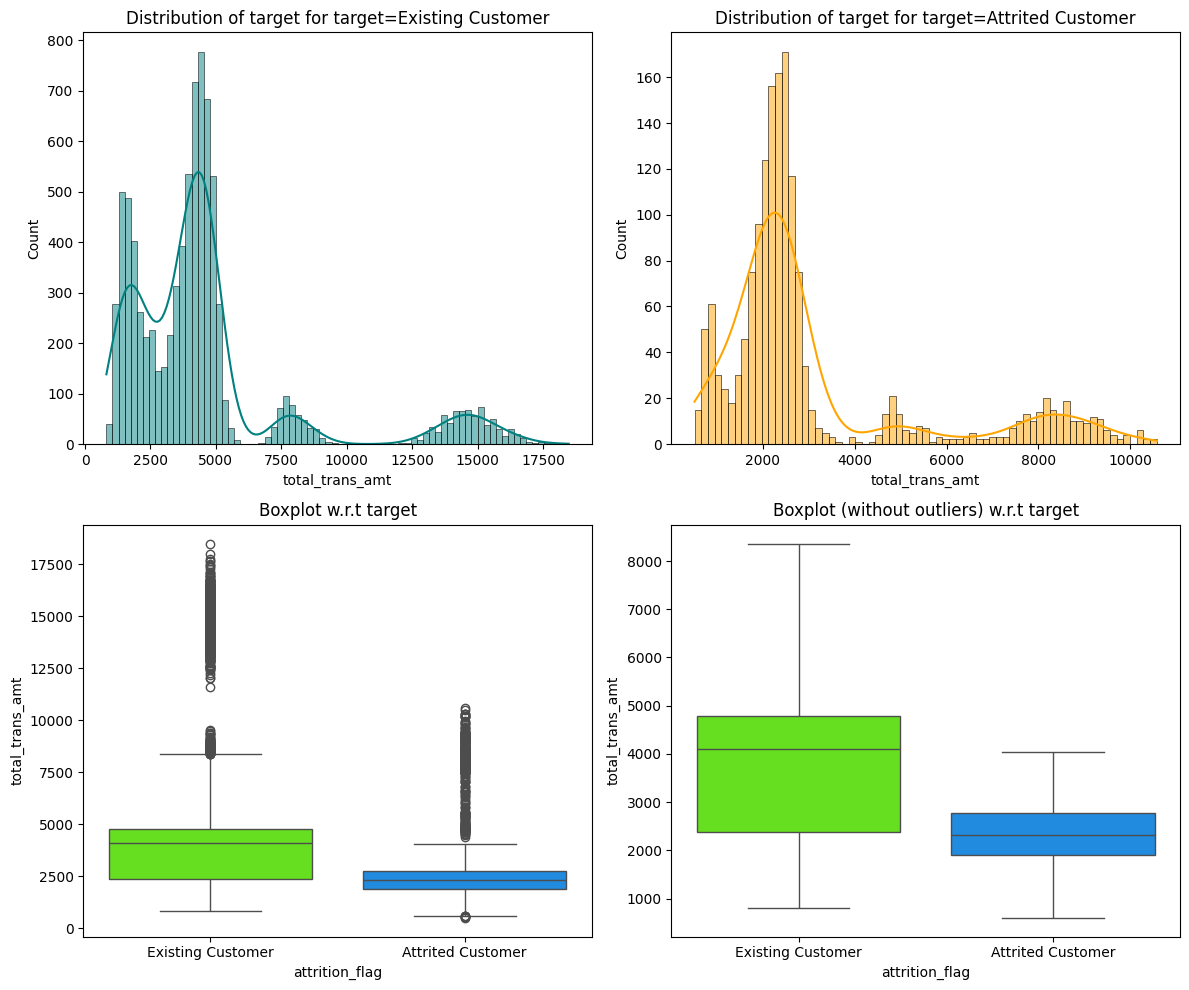

In [50]:
distribution_plot_wrt_target(df, 'total_trans_amt', 'attrition_flag')

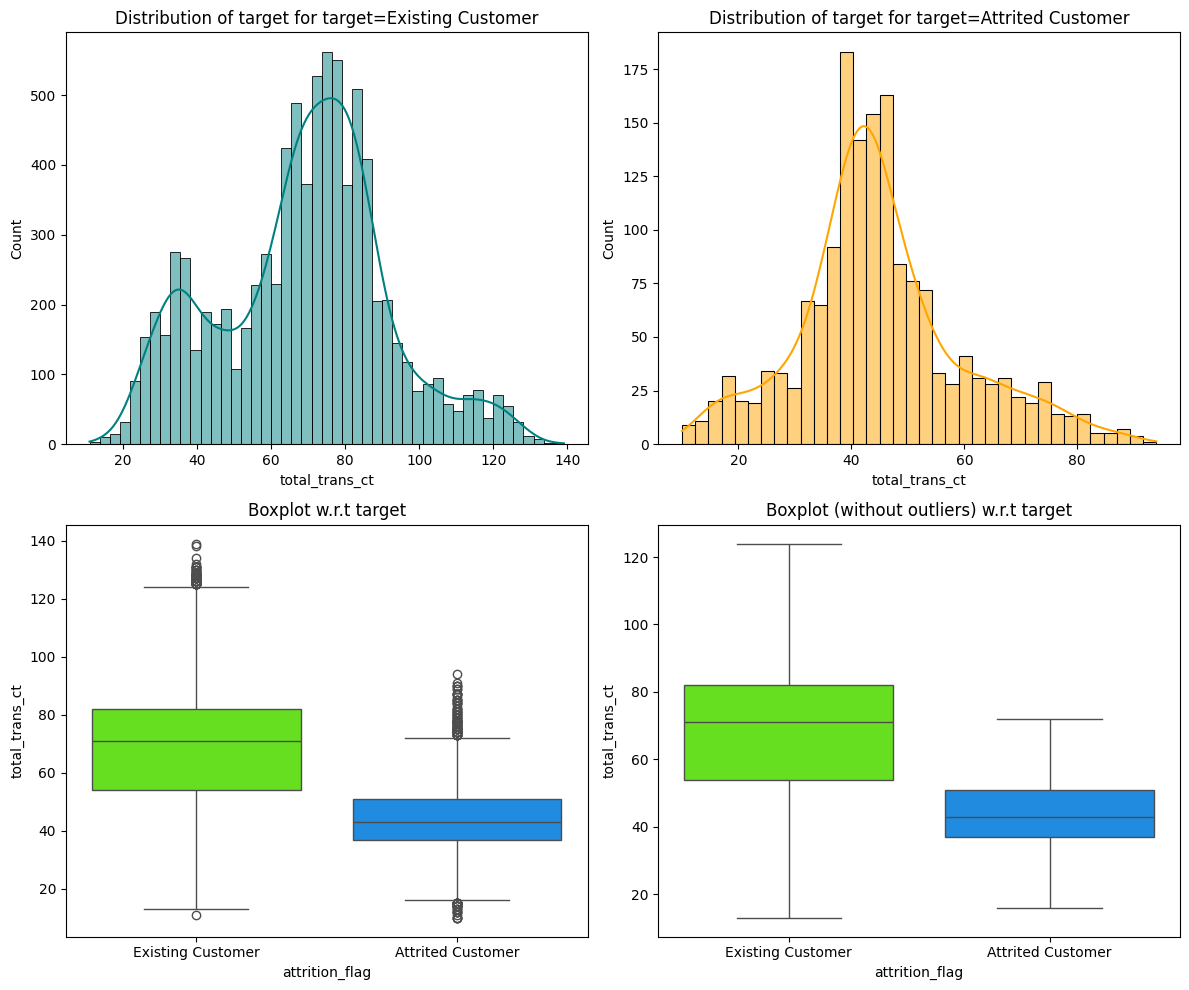

In [51]:
distribution_plot_wrt_target(df, 'total_trans_ct', 'attrition_flag')

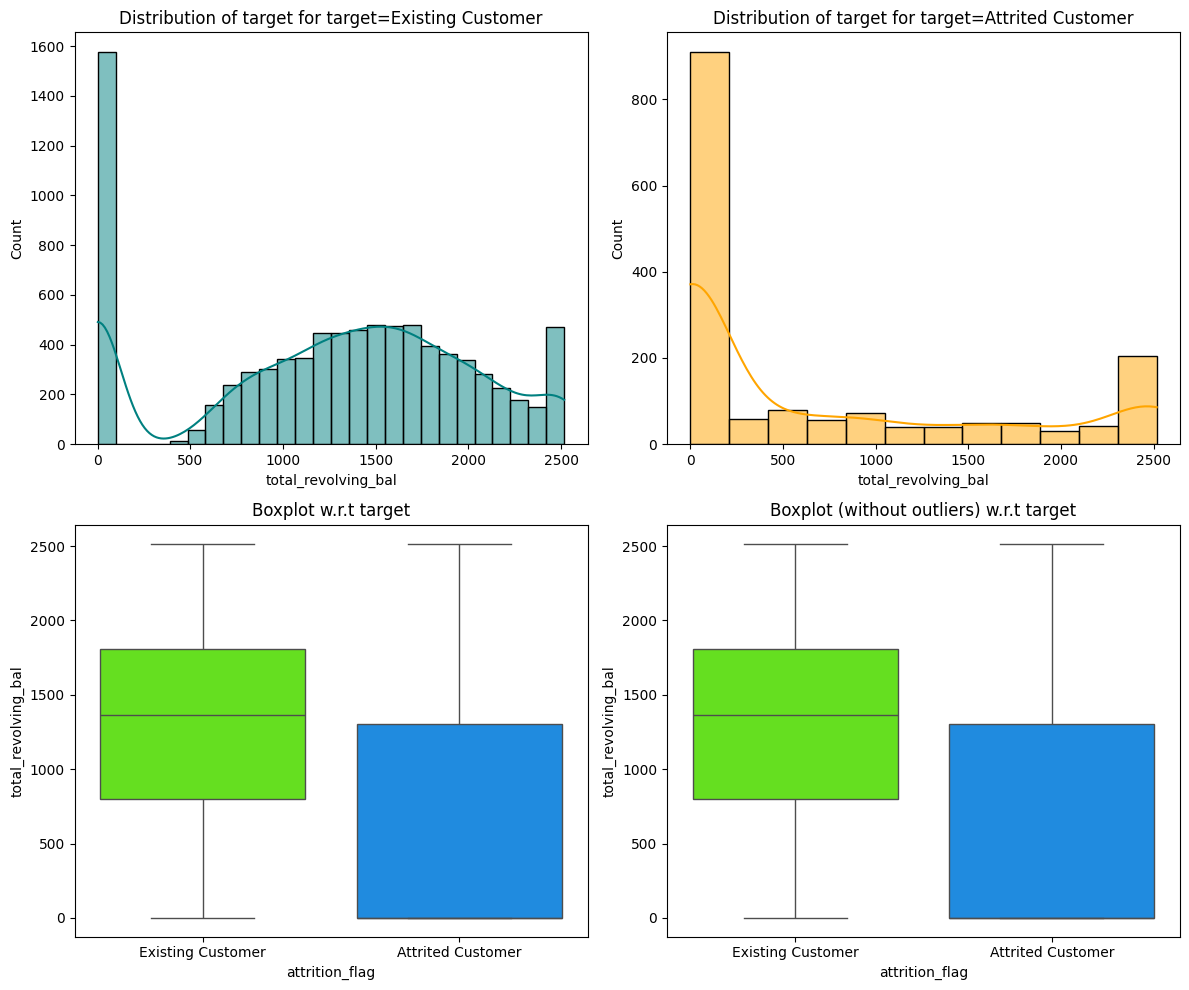

In [52]:
distribution_plot_wrt_target(df, 'total_revolving_bal', 'attrition_flag')

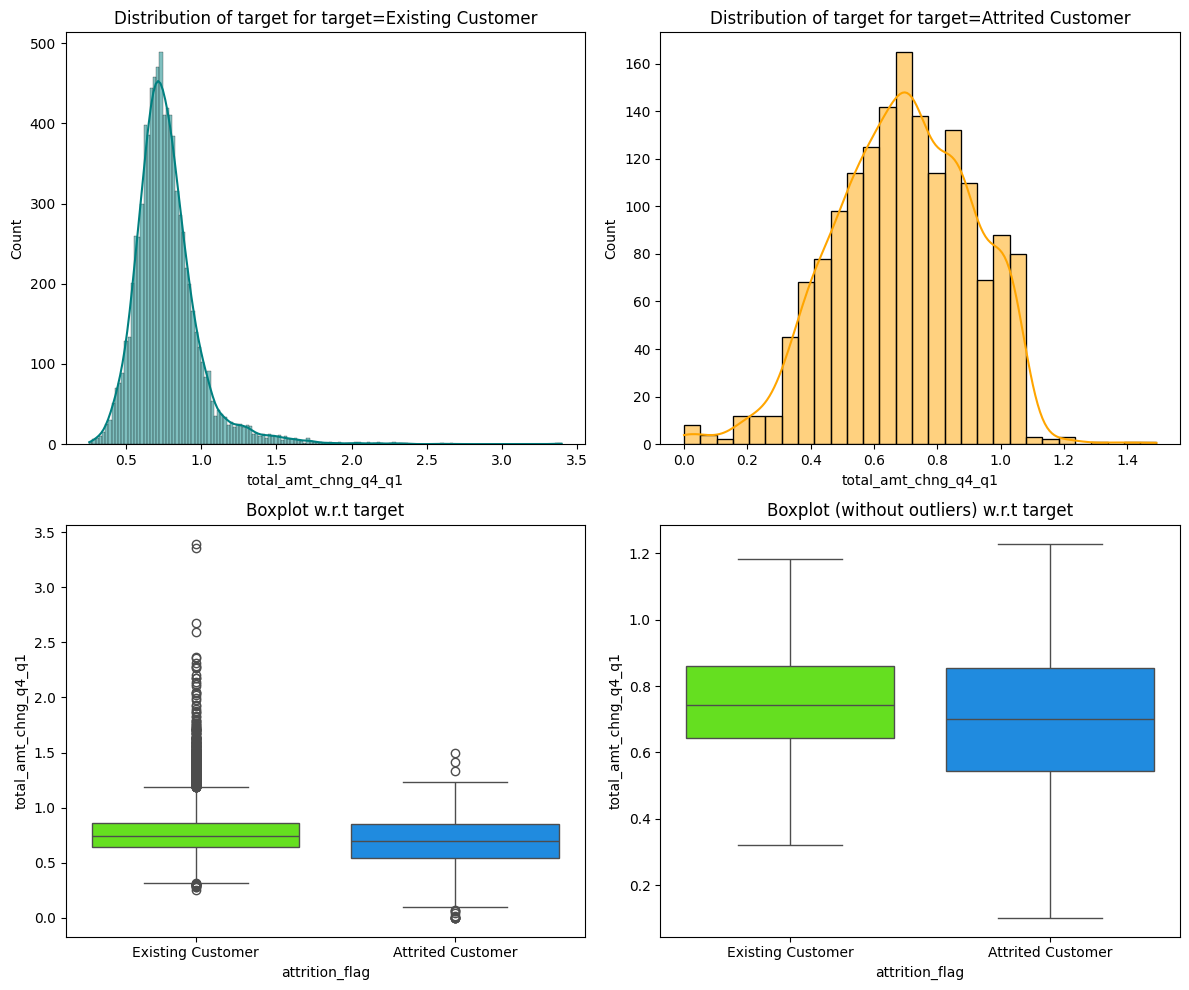

In [53]:
distribution_plot_wrt_target(df, 'total_amt_chng_q4_q1', 'attrition_flag')

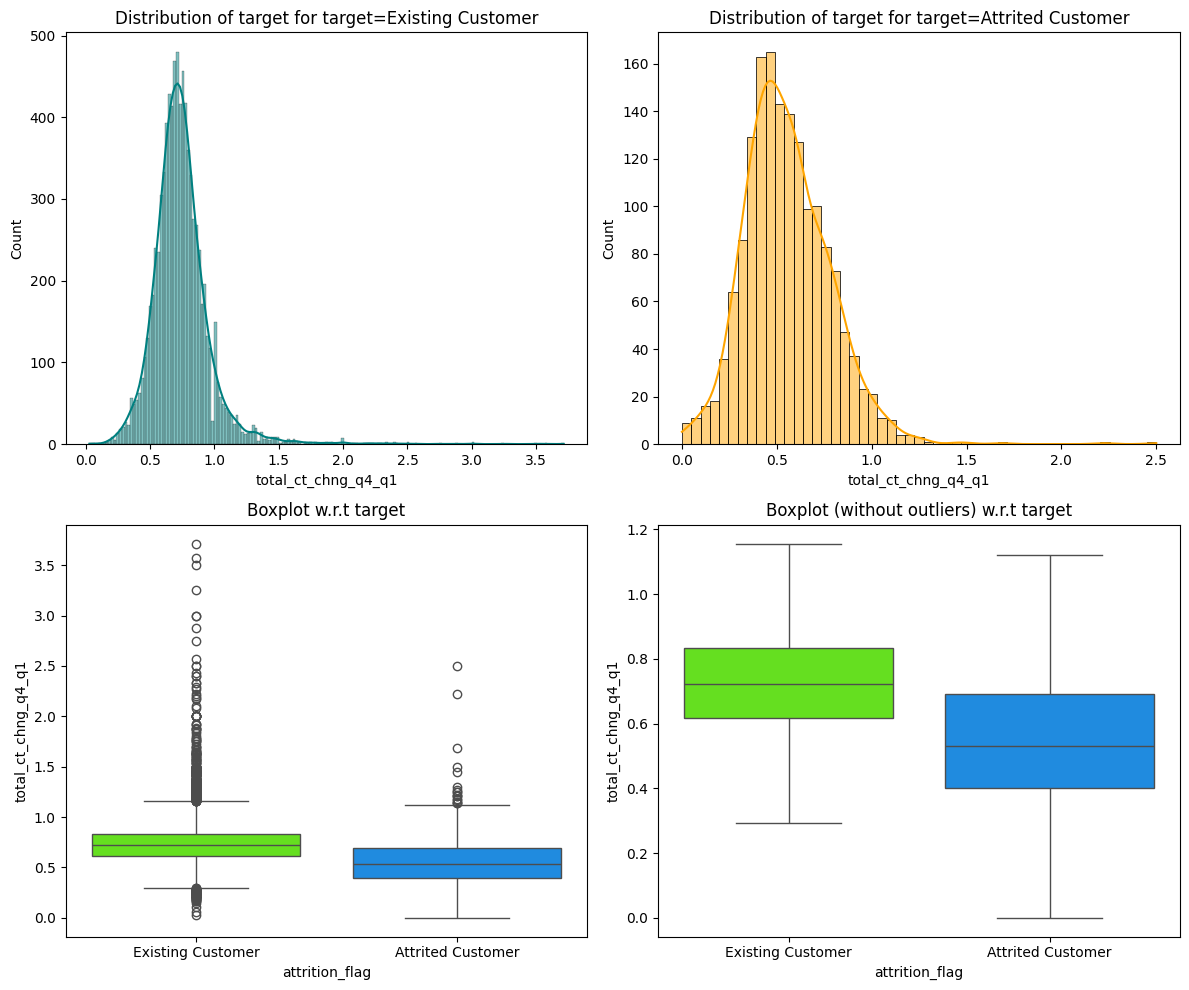

In [54]:
distribution_plot_wrt_target(df, 'total_ct_chng_q4_q1', 'attrition_flag')

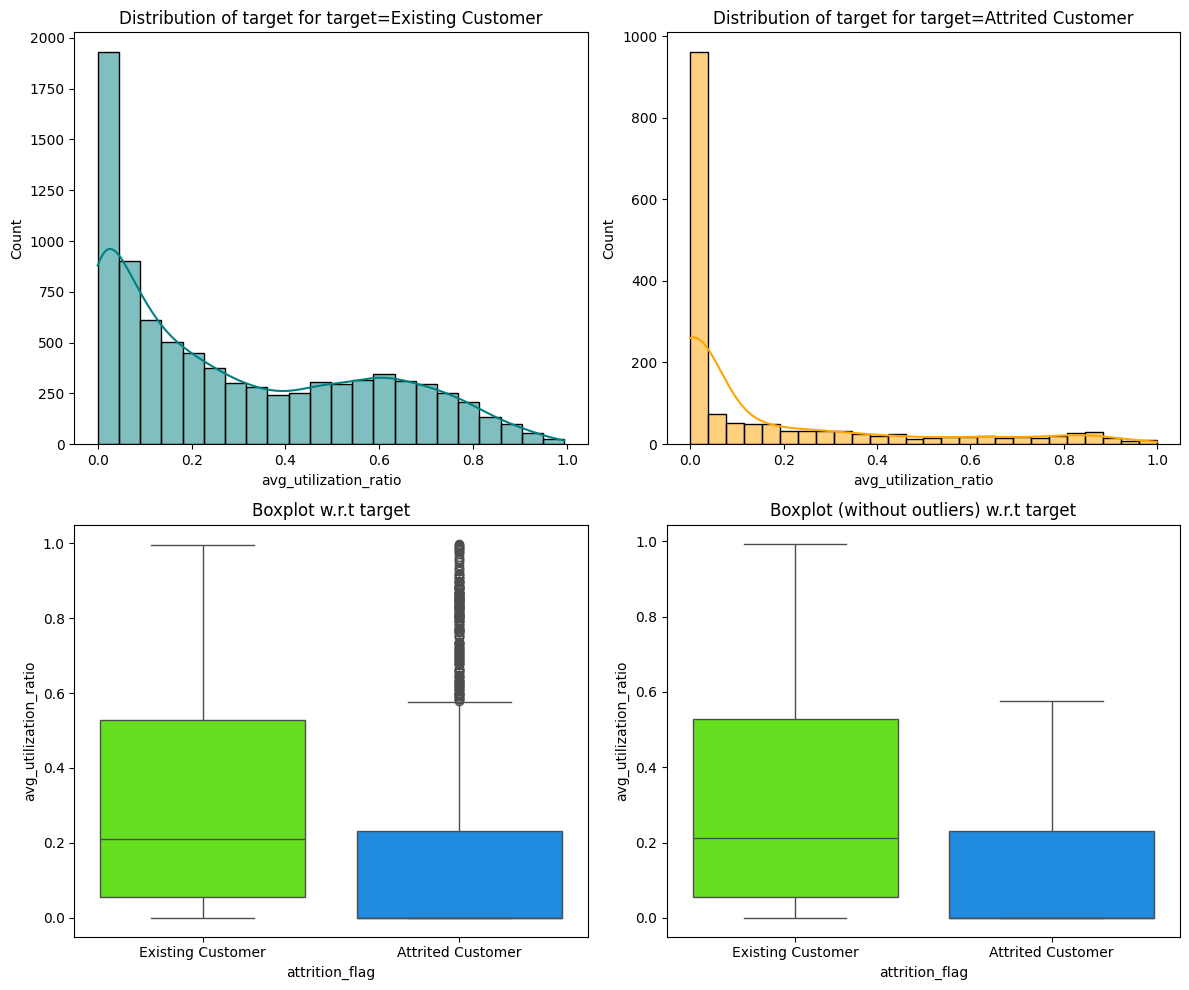

In [55]:
distribution_plot_wrt_target(df, 'avg_utilization_ratio', 'attrition_flag')



*   The existing customers utilize their card more.  This makes sense as they're active customers.
*   The IQR look the same regardless of attrition.



attrition_flag   Attrited Customer  Existing Customer   All
income_category                                            
All                           1440               7575  9015
Less than $40K                 612               2949  3561
$40K - $60K                    271               1519  1790
$80K - $120K                   242               1293  1535
$60K - $80K                    189               1213  1402
$120K +                        126                601   727




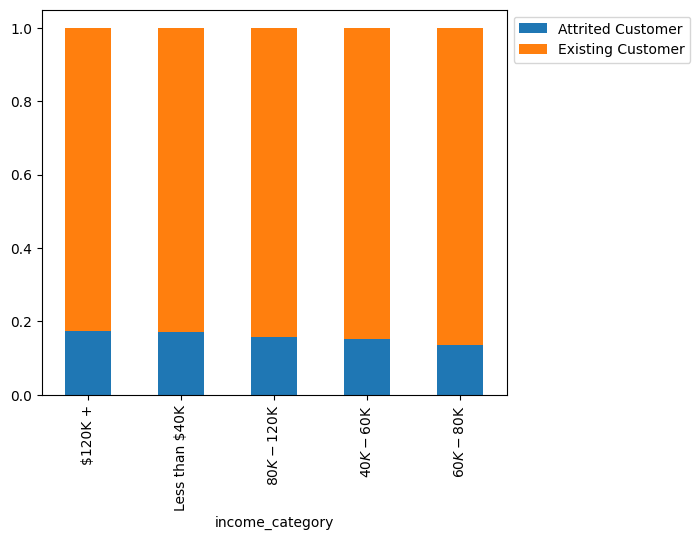

In [56]:
stacked_barplot(df, 'income_category', 'attrition_flag')

Income Category appears to be not effected by attrition.

attrition_flag  Attrited Customer  Existing Customer    All
card_category                                              
All                          1627               8500  10127
Blue                         1519               7917   9436
Silver                         82                473    555
Gold                           21                 95    116
Platinum                        5                 15     20




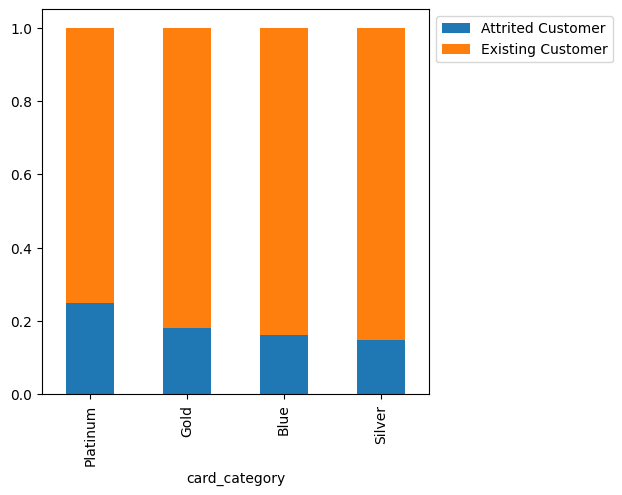

In [57]:
stacked_barplot(df, 'card_category', 'attrition_flag')

*   Most customers use the Platinum card.
*   Blue and silver card members are almost the same.



attrition_flag  Attrited Customer  Existing Customer    All
gender                                                     
All                          1627               8500  10127
F                             930               4428   5358
M                             697               4072   4769




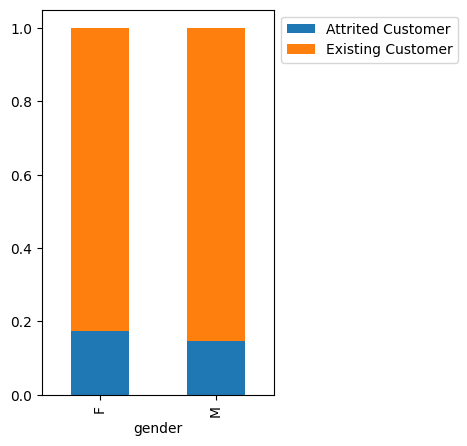

In [58]:
stacked_barplot(df, 'gender', 'attrition_flag')

Gender difference is negligible.

attrition_flag            Attrited Customer  Existing Customer    All
total_relationship_count                                             
All                                    1627               8500  10127
3                                       400               1905   2305
2                                       346                897   1243
1                                       233                677    910
5                                       227               1664   1891
4                                       225               1687   1912
6                                       196               1670   1866




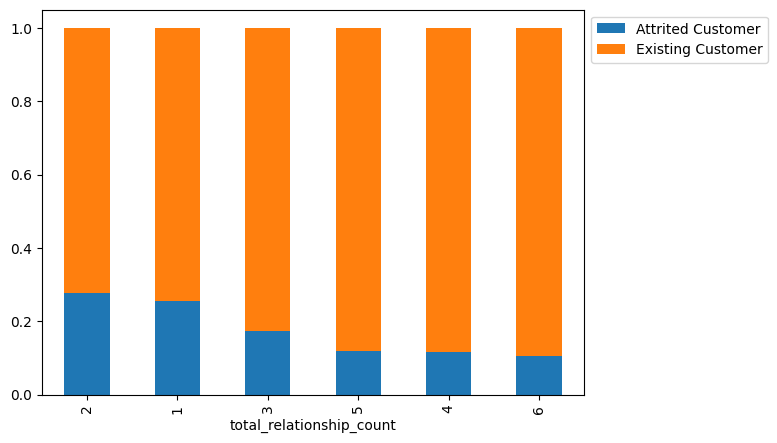

In [59]:
stacked_barplot(df, 'total_relationship_count', 'attrition_flag')

There are more former customers that have fewer products than the existing ones.

attrition_flag   Attrited Customer  Existing Customer   All
education_level                                            
All                           1371               7237  8608
Graduate                       487               2641  3128
High School                    306               1707  2013
Uneducated                     237               1250  1487
College                        154                859  1013
Doctorate                       95                356   451
Post-Graduate                   92                424   516




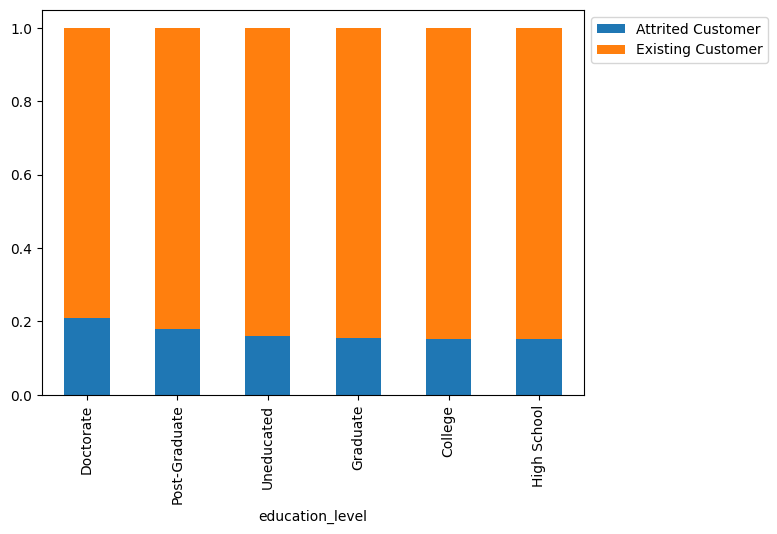

In [60]:
stacked_barplot(df, 'education_level', 'attrition_flag')

Education is negligible.

attrition_flag         Attrited Customer  Existing Customer    All
contacts_count_12_mon                                             
All                                 1627               8500  10127
3                                    681               2699   3380
2                                    403               2824   3227
4                                    315               1077   1392
1                                    108               1391   1499
5                                     59                117    176
6                                     54                  0     54
0                                      7                392    399




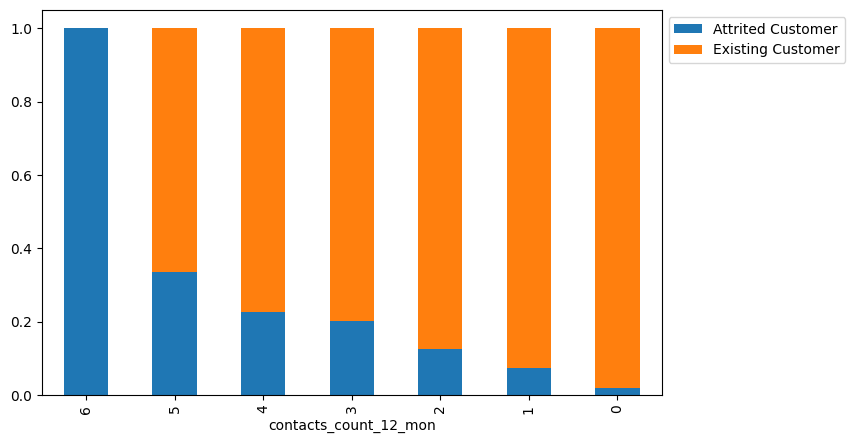

In [61]:
stacked_barplot(df, 'contacts_count_12_mon', 'attrition_flag')


*   The bank has contacted attrited customers more frequently than existing ones.
*   In fact there has been no contact w/ existing customers.
*  The longer a customer is no longer existing the more frequent the contact to get them to return.



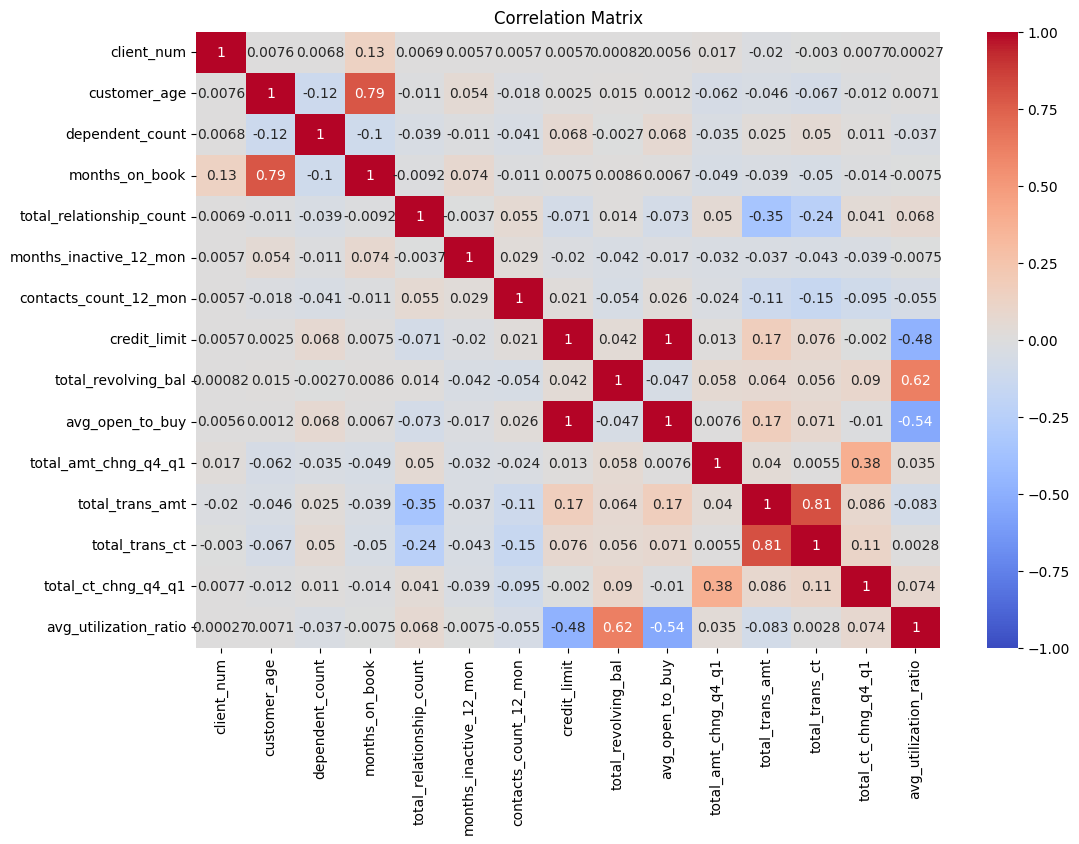

In [62]:
# Assume df is your DataFrame with numerical attributes
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

The strongest correlations are:


1.   Total Transaction Amount & Total Transaction Count (0.81)
2.   Customer Age & Month on Books (0.79)
3. Total Revolving Balance & Average Utilization Ratio (0.64)
4. Credit Limit and average open to buy has the strongest correlation (1.0)




In [63]:
# ===========================================
#  CREATE TRAINING, VALIDATION, TESTING DATA
# ===========================================
#
# Training Data - 70%
# Validation Data - 15%
# Testing Data - 15%

'''
DATA_TEMP_SPLIT = 0.3
DATA_TRAINING_SPLIT = 0.7
DATA_TESTING_SPLIT = 0.15
DATA_VALIDATION_SPLIT = 0.15
'''

# INDEPENDENT VARIABLES
df_independent = X = df.drop('attrition_flag', axis=1)

# DEPENDENT VARIABLE
df_dependent = y = df['attrition_flag']

'''
df_independent_vars_training_data = None
df_independent_vars_temp_data = None
df_dependent_var_training_data = None
df_dependent_var_temp_data = None

df_independent_vars_validation_data = None
df_independent_vars_testing_data = None
df_dependent_var_validation_data = None
df_dependent_var_testing_data = None
'''

x_training_data = None
y_training_data = None
x_temp_data = None
y_temp_data = None

x_validation_data = None
y_validation_data = None
x_testing_data = None
y_testing_data = None

# --- Split data into 70% training data and 30% temporary data --- #
x_training_data, x_temp_data, y_training_data, y_temp_data = train_test_split(
    df_independent,
    df_dependent,
    test_size=DATA_TEMP_SPLIT,
    random_state=SEED,
    stratify=df_dependent
)

# --- Then take remaining temporary data 30% and split in half --- #
x_validation_data, x_testing_data, y_validation_data, y_testing_data = train_test_split(
    x_temp_data,
    y_temp_data,
    test_size=HALF_SPLIT,
    random_state=SEED,
    stratify=y_temp_data
)

In [64]:
x_training_data

,client_num,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
4677,714479358,51,M,3,Graduate,Single,$80K - $120K,Blue,36,6,3,3,3610.000,1554,2056.000,0.501,2216,34,0.308,0.430
8337,712747758,50,F,4,Uneducated,Single,Less than $40K,Blue,36,2,2,3,2477.000,0,2477.000,0.445,2037,43,0.387,0.000
1560,711285633,33,F,0,NaN,Single,NaN,Blue,36,6,1,3,2735.000,1769,966.000,1.465,3306,71,0.972,0.647
385,794545983,57,M,2,Graduate,Married,$80K - $120K,Blue,40,3,2,3,12208.000,1980,10228.000,0.616,1409,34,0.619,0.162
5363,802247658,59,M,2,Uneducated,Single,$40K - $60K,Blue,53,4,5,4,2699.000,2422,277.000,0.773,2599,43,0.433,0.897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3816,710673558,37,M,1,High School,Single,$60K - $80K,Blue,21,3,2,2,21952.000,1600,20352.000,0.878,4087,70,0.628,0.073
1813,720158208,37,M,3,Graduate,Married,$60K - $80K,Blue,23,4,3,2,3034.000,2167,867.000,0.711,2058,49,0.485,0.714
2196,718435158,50,M,3,High School,Married,$120K +,Blue,40,5,1,4,34516.000,0,34516.000,0.986,1930,36,0.440,0.000
2061,720171033,45,M,4,NaN,Married,$60K - $80K,Blue,36,6,1,1,11498.000,1577,9921.000,0.756,4014,70,0.489,0.137


In [65]:
# TODO: @deprecated

X = df.drop('attrition_flag', axis=1)
y = df['attrition_flag']

# --- Training 70%, Validation 15%, Test 15% ---

# Split data into 70% training data and 30% temporary data
#X_train, X_temp, y_train, y_temp = train_test_split(
#    X, y, test_size=0.3
# Now let's take the 30% temporary data and split equally between validation and test data



# First we split data into 2 parts, say temporary and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.5, random_state=SEED, stratify=y
)

# Then we split the temporary set into train and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=SEED, stratify=y_temp
)

print(x_training_data.shape, X_val.shape, X_test.shape)

(7088, 20) (3038, 20) (2026, 20)


## Missing value imputation




In [66]:
# Missing value imputation
df['education_level'].replace(['unknown', 'abc'], 'Unknown', inplace=True)

impute_columns = ['education_level', 'marital_status', 'income_category']
imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")

# Fit and transform the train data
x_training_data[impute_columns] = imputer.fit_transform(x_training_data[impute_columns])

# Transform the validation data
x_validation_data[impute_columns] = imputer.transform(x_validation_data[impute_columns])

# Transform the test data
x_testing_data[impute_columns] = imputer.transform(x_testing_data[impute_columns])

# Show values
show_banner("Attrition Information", "Target value ratio in `y`")

print(df_dependent.value_counts(1))

print("Target value ratio in y_train\n")
print(y_training_data.value_counts(1))

print("Target value ratio in y_val\n")
print(y_validation_data.value_counts(1))

print("Target value ratio in y_test\n")
print(y_testing_data.value_counts(1))

# =======================
#  Attrition Information
# =======================

 Target value ratio in `y`


attrition_flag
Existing Customer   0.839
Attrited Customer   0.161
Name: proportion, dtype: float64
Target value ratio in y_train

attrition_flag
Existing Customer   0.839
Attrited Customer   0.161
Name: proportion, dtype: float64
Target value ratio in y_val

attrition_flag
Existing Customer   0.839
Attrited Customer   0.161
Name: proportion, dtype: float64
Target value ratio in y_test

attrition_flag
Existing Customer   0.839
Attrited Customer   0.161
Name: proportion, dtype: float64


## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [67]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target) -> pd.DataFrame:
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred) # to compute Accuracy
    recall = recall_score(target, pred) # to compute Recall
    precision = precision_score(target, pred) # to compute Precision
    f1 = f1_score(target, pred) # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Model Building with original data

In [78]:
# Build Model with original data
def build_model():

    models = []  # Empty list to store all the models

    # Appending models into the list
    models.append(('Bagging', BaggingClassifier(
        random_state=SEED,
        n_estimators=BASE_ESTIMATOR_CNT)
      )
    )
    models.append(('Random forest', RandomForestClassifier(
        max_depth=NODE_RFC_CNT,
        n_estimators=UNTUNED_ESTIMATOR_CNT,
        min_samples_split=10,
        min_samples_leaf=5)
      )
    )

    # Appendinig extra models to perfect data
    models.append(('AdaBoost', AdaBoostClassifier(random_state=SEED)))
    models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=SEED)))
    models.append(('XGBoost', XGBClassifier(
        n_estimators=UNTUNED_ESTIMATOR_CNT,
        max_depth=NODE_XGBC_CNT,
        learning_rate= UNTUNED_LEARNING_RATE,
        reg_alpha=0.3,
        reg_lambda=0.3)
      )
    )

    return models


def show_fit_model_scores(
    mods: list,
    x_fit_data: pd.DataFrame,
    y_fit_data: pd.Series,
    x_data: pd.DataFrame,
    y_data: pd.Series
    ) -> None:

    for name, model in mods:
        model.fit(x_fit_data, y_fit_data)
        scores_val = recall_score(y_data, model.predict(x_data))
        print("{}: {}".format(name, scores_val))


def show_classification_model_perf(mods, x_data: pd.DataFrame, y_data: pd.Series):
    for name, model in mods:
        df_perf = model_performance_classification_sklearn(model, x_data, y_data)
        print(df_perf)


def run_model_performance(
    mods: list,
    x_fit_data: pd.DataFrame,
    y_fit_data: pd.Series,
    x_data: pd.DataFrame,
    y_data: pd.Series,
    section: str="",
    show_classify: bool=False
    ) -> None:

    '''
    mods: - list of models

    data_y: dependent variable
    data_x: independent variables
    section: str - title of the section
    show_classify: bool - determines which performance function to run

    Starts time for benchmarking, displays banner for readability and shows model performance.
    '''
    start_time = start_timer()
    show_banner(title, section)

    if show_classify:
        show_classification_model_perf(mods, x_data, y_data)
    else:
        show_fit_model_scores(mods, x_fit_data, y_fit_data, x_data, y_data)

    show_timer(start_time)

In [69]:
# Find categorical features
numerical_labels = {'Existing Customer': 0, 'Attrited Customer': 1}
categorical_cols = x_training_data.select_dtypes(include=['object']).columns

encoder = ce.OrdinalEncoder(cols=categorical_cols)

# Fit and transform the training data
x_training_data = encoder.fit_transform(x_training_data)

# Transform the validation data
x_validation_data = encoder.transform(x_validation_data)

# Transform the test data
x_testing_data = encoder.transform(x_testing_data)

# Convert target variable to numerical labels
y_training_data = y_training_data.map(numerical_labels)

# Assuming you have a y_val, convert it as well
y_validation_data = y_validation_data.map(numerical_labels)
y_testing_data = y_testing_data.map(numerical_labels)

show_banner('Split Data Shapes')

print("x_training_data shape:", x_training_data.shape)
print("y_training_data shape:", y_training_data.shape)
print("x_validation_data shape:", x_validation_data.shape)
print("y_validation_data shape:", y_validation_data.shape)
print("x_testing_data shape:", x_testing_data.shape)
print("y_testing_data shape:", y_testing_data.shape)

# Checking information of new data frame's columns.
show_banner('Train Information')
x_training_data.info()

show_banner('Validation Information')
x_validation_data.info()

show_banner('Test Information')
x_testing_data.info()

# ===================
#  Split Data Shapes
# ===================

x_training_data shape: (7088, 20)
y_training_data shape: (7088,)
x_validation_data shape: (1519, 20)
y_validation_data shape: (1519,)
x_testing_data shape: (1520, 20)
y_testing_data shape: (1520,)
# ===================
#  Train Information
# ===================

<class 'pandas.core.frame.DataFrame'>
Index: 7088 entries, 4677 to 9403
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_num                7088 non-null   int64  
 1   customer_age              7088 non-null   int64  
 2   gender                    7088 non-null   int64  
 3   dependent_count           7088 non-null   int64  
 4   education_level           7088 non-null   int64  
 5   marital_status            7088 non-null   int64  
 6   income_category           7088 non-null   int64  
 7   card_category             7088 non-null   int64  
 8   months_on_b

In [70]:
# Check for NaN's
print(f'Training Data: {y_training_data.isnull().sum()}')  # Check for any NaN values
print(f'Validation Data: {y_validation_data.isnull().sum()}')  # Check for any NaN values
print(f'Testing Data: {y_testing_data.isnull().sum()}')  # Check for any NaN values

# Drop rows in X_train and y_train where y_train has NaN values
y_training_data = y_training_data.dropna()
x_training_data = x_training_data.loc[y_training_data.index]  # Keep only rows in X_train that match y_train's index

if y_training_data.empty:
    print('Warning! Target training data is empty after dropping NaNs. Imputation cannot be performed.')

else:
    y_training_data = y_training_data.fillna(y_training_data.mode()[0])  # Impute only if y_train is not empty

Training Data: 0
Validation Data: 0
Testing Data: 0


Note: *y_train, y_val, y_test all have had NaN values removed!*

Sample code for model building with original data



*   **Gradiant Boosting** has the highest performance for training.
*   **Bagging** and **Gradient Boosting** are tied for the highest performance for validation.



In [71]:
title = 'Original Data Model'

In [72]:
# Build model with original data
# After building models, show training, validation and classification performance
models = build_model()

In [73]:
run_model_performance(models, x_training_data, y_training_data, x_training_data, y_training_data, 'Training Performance')

# =====================
#  Original Data Model
# =====================

 Training Performance


Bagging: 1.0
Random forest: 0.5285338015803336
AdaBoost: 0.7778753292361721
Gradient Boosting: 0.8902546093064091
XGBoost: 0.7190517998244074
Run Time: 0m 16s 340ms


In [74]:
run_model_performance(models, x_training_data, y_training_data, x_validation_data, y_validation_data, 'Validation Performance')

# =====================
#  Original Data Model
# =====================

 Validation Performance


Bagging: 0.8360655737704918
Random forest: 0.45081967213114754
AdaBoost: 0.6885245901639344
Gradient Boosting: 0.7868852459016393
XGBoost: 0.6557377049180327
Run Time: 0m 12s 323ms


In [79]:
run_model_performance(models, None, None, x_training_data, y_training_data, 'Classification by Model(s)', True)

# =====================
#  Original Data Model
# =====================

 Classification by Model(s)


   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
   Accuracy  Recall  Precision    F1
0     0.916   0.538      0.896 0.673
   Accuracy  Recall  Precision    F1
0     0.949   0.778      0.894 0.832
   Accuracy  Recall  Precision    F1
0     0.976   0.890      0.958 0.923
   Accuracy  Recall  Precision    F1
0     0.947   0.719      0.933 0.812
Run Time: 0m 0s 436ms


### Model Building with Oversampled data


In [80]:
# ==================================
#  OVERSAMPLED DATA
# ==================================
title = 'Oversampled Data Models'

In [81]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=SEED)
x_training_oversample, y_training_oversample = sm.fit_resample(x_training_data, y_training_data)

print(sm)

SMOTE(random_state=42, sampling_strategy=1)


In [82]:
# Build Model
oversample_models = build_model()

In [84]:
type(x_training_oversample)

pandas.core.frame.DataFrame

In [85]:
run_model_performance(oversample_models, x_training_oversample, y_training_oversample, x_training_oversample, y_training_oversample, 'Training Performance')

# =========================
#  Oversampled Data Models
# =========================

 Training Performance


Bagging: 1.0
Random forest: 0.9041855774079677
AdaBoost: 0.9428475374012439
Gradient Boosting: 0.9704151958312321
XGBoost: 0.957135653050933
Run Time: 0m 23s 879ms


In [87]:
run_model_performance(oversample_models, x_training_oversample, y_training_oversample, x_validation_data, y_validation_data, 'Validation Performance')

# =========================
#  Oversampled Data Models
# =========================

 Validation Performance


Bagging: 0.8688524590163934
Random forest: 0.8114754098360656
AdaBoost: 0.8442622950819673
Gradient Boosting: 0.8852459016393442
XGBoost: 0.8647540983606558
Run Time: 0m 30s 532ms


In [89]:
run_model_performance(oversample_models, None, None, x_training_oversample, y_training_oversample, 'Classification by Model(s)', True)

# =========================
#  Oversampled Data Models
# =========================

 Classification by Model(s)


   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
   Accuracy  Recall  Precision    F1
0     0.900   0.922      0.884 0.903
   Accuracy  Recall  Precision    F1
0     0.926   0.943      0.912 0.927
   Accuracy  Recall  Precision    F1
0     0.965   0.970      0.959 0.965
   Accuracy  Recall  Precision    F1
0     0.932   0.957      0.912 0.934
Run Time: 0m 1s 169ms


We can see that the model with oversampled data has improved.
There is some overfitting in the results.

### Model Building with Undersampled data

In [90]:
# ==================================
#  UNDERSAMPLED DATA
# ==================================
title = 'Undersampled Data Models'

In [91]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=SEED, sampling_strategy=1)
x_training_undersample, y_training_undersample = rus.fit_resample(x_training_data, y_training_data)

In [92]:
undersample_models = build_model()

In [93]:
run_model_performance(undersample_models, x_training_undersample, y_training_undersample, x_training_undersample, y_training_undersample, 'Training Performance')

# ==========================
#  Undersampled Data Models
# ==========================

 Training Performance


Bagging: 1.0
Random forest: 0.913081650570676
AdaBoost: 0.9455662862159789
Gradient Boosting: 0.9850746268656716
XGBoost: 0.9482001755926251
Run Time: 0m 6s 837ms


In [94]:
run_model_performance(undersample_models, x_training_undersample, y_training_undersample, x_validation_data, y_validation_data, 'Validation Performance')

# ==========================
#  Undersampled Data Models
# ==========================

 Validation Performance


Bagging: 0.9262295081967213
Random forest: 0.8483606557377049
AdaBoost: 0.9098360655737705
Gradient Boosting: 0.930327868852459
XGBoost: 0.8975409836065574
Run Time: 0m 4s 425ms


In [96]:
run_model_performance(undersample_models, None, None, x_training_undersample, y_training_undersample, 'Classification by Model(s)', True)

# ==========================
#  Undersampled Data Models
# ==========================

 Classification by Model(s)


   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
   Accuracy  Recall  Precision    F1
0     0.906   0.916      0.898 0.907
   Accuracy  Recall  Precision    F1
0     0.941   0.946      0.937 0.941
   Accuracy  Recall  Precision    F1
0     0.980   0.985      0.975 0.980
   Accuracy  Recall  Precision    F1
0     0.933   0.948      0.920 0.934
Run Time: 0m 0s 298ms


In [107]:
def plot_confusion_matrix(model, X, y_true):
    """
    Generates a heatmap for the confusion matrix of a given model and dataset.

    Parameters:
    model: Trained model
    X: Feature data to make predictions
    y_true: True target labels

    Returns:
    Heatmap showing TP, FP, TN, FN.
    """

    # Predict the target for the given features
    y_pred = model.predict(X)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Calculate percentages for each cell in the confusion matrix
    cm_percentage = cm / cm.sum() * PERCENTILE

    # Add a label to chart.
    labels = np.asarray([
        [f"{int(cm[i, j])}\n{cm_percentage[i, j]:.2f}%" for j in range(len(cm))]
        for i in range(len(cm))
    ])

    # Display the confusion matrix as a heatmap
    plt.figure(figsize=(6, 4))
    hm = sns.heatmap(cm, annot=labels, fmt='', cbar=False,
                xticklabels=model.classes_, yticklabels=model.classes_)


    plt.title("Confusion Matrix Heatmap")
    plt.show()

    # Extract TP, FP, TN, FN and print them
    TN, FP, FN, TP = cm.ravel()

    print(f"\nTrue Positives (TP): {TP}")
    print(f"False Positives (FP): {FP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Negatives (FN): {FN}")

In [219]:
def pick_top_model(xgb_model_scores: pd.DataFrame, xgb_models: list) -> XGBClassifier :
    '''
    xgb_models: pd.DataFrame

    Compares the three XGBoost models and returns the best one.
    '''
    top_m = None
    top_m_title = ''
    f1_scores = []

    # Get F1 Scores
    for model in xgb_model_scores.columns:
        f1_scores.append(xgb_model_scores[model]['F1'])

    # Get index and variable of top F1 score
    top_m_index = f1_scores.index(max(f1_scores))
    top_m_title = xgb_model_scores.columns[top_m_index]
    top_m = xgb_models[top_m_index]

    show_banner('TOP MODEL', top_m_title)
    print(xgb_model_scores[top_m_title]) # Fixed line: Use top_m_title (string) instead of top_m_index (integer)

    return top_m

### HyperparameterTuning

#### Sample Parameter Grids

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase


- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=SEED),DecisionTreeClassifier(random_state=SEED)],
    "n_estimators": np.arange(50, 110, 25),),
    "learning_rate": [0.01, 0.1, 0.05],],
    "subsample":[0.7, 0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=SEED),
        DecisionTreeClassifier(max_depth=3, random_state=SEED),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost (optional):

```
param_grid={'n_estimators':np.arange(50, 110, 25),
            'scale_pos_weight':[1, 2, 5],
            'learning_rate':[0.01, 0.1, 0.05],
            'gamma':[1, 3],
            'subsample':[0.7, 0.9]
}
```

#### Sample tuning method for Decision tree with original data

Choosing models to see which is the best...

In [99]:
DECISION_TREE_PARAMS = {
    "init": [
        AdaBoostClassifier(random_state=SEED),
        DecisionTreeClassifier(random_state=SEED)
        ],
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "subsample": [0.7, 0.9],
    "max_features": [0.5, 0.7, 1],
}

In [100]:
# Gradiant Boosting
start_time = start_timer()

gbc = GradientBoostingClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=DECISION_TREE_PARAMS,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
    )

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_data, y_training_data)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(75), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=42)} with CV score=0.9276364648288679:


In [101]:
# Tuned Gradiant Boosting
gbc_tuned = GradientBoostingClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT
)

gbc_tuned.fit(x_training_data, y_training_data)

GradientBoostingClassifier(max_features=0.5, n_estimators=20, random_state=42,
                           subsample=0.7)

In [102]:
# Checking GBC tuned model peformance
gbc_tuned_scores = model_performance_classification_sklearn(gbc_tuned, x_training_data, y_training_data)

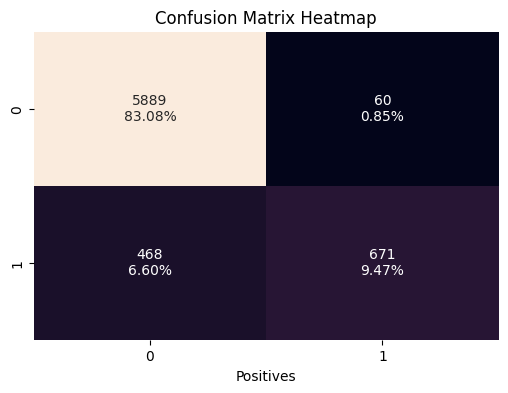


True Positives (TP): 671
False Positives (FP): 60
True Negatives (TN): 5889
False Negatives (FN): 468


In [106]:
plot_confusion_matrix(gbc_tuned, x_training_data, y_training_data)

In [108]:
gbc_tuned_validation_scores = model_performance_classification_sklearn(gbc_tuned, x_validation_data, y_validation_data)

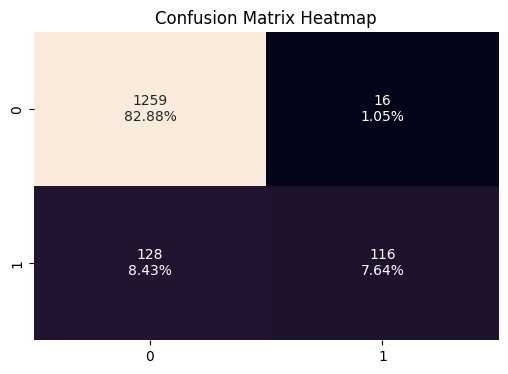


True Positives (TP): 116
False Positives (FP): 16
True Negatives (TN): 1259
False Negatives (FN): 128


In [109]:
plot_confusion_matrix(gbc_tuned, x_validation_data, y_validation_data)

Gradient Boost Oversampled

In [110]:
start_time = start_timer()
gbc_oversample = GradientBoostingClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=gbc_oversample,
    param_distributions=DECISION_TREE_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
    )

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_oversample, y_training_oversample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.1, 'init': DecisionTreeClassifier(random_state=42)} with CV score=0.9300583861003497:


In [111]:
# Tuned Gradiant Boosting
gbc_tuned_oversample = GradientBoostingClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT
)

gbc_tuned_oversample.fit(x_training_oversample, y_training_oversample)

GradientBoostingClassifier(max_features=0.5, n_estimators=20, random_state=42,
                           subsample=0.7)

In [112]:
# Checking GBC tuned model peformance
gbc_tuned_oversample_scores = model_performance_classification_sklearn(gbc_tuned_oversample, x_training_oversample, y_training_oversample)

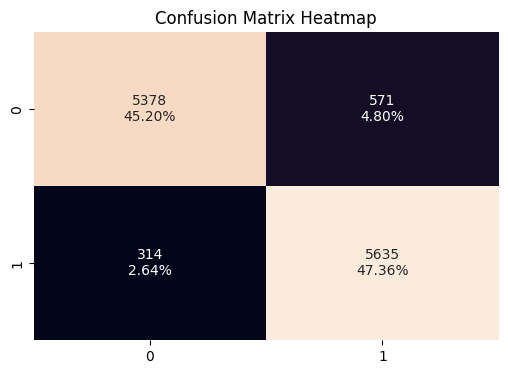


True Positives (TP): 5635
False Positives (FP): 571
True Negatives (TN): 5378
False Negatives (FN): 314


In [113]:
plot_confusion_matrix(gbc_tuned_oversample, x_training_oversample, y_training_oversample)

In [115]:
gbc_tuned_oversample_validation_scores = model_performance_classification_sklearn(gbc_tuned_oversample, x_validation_data, y_validation_data)

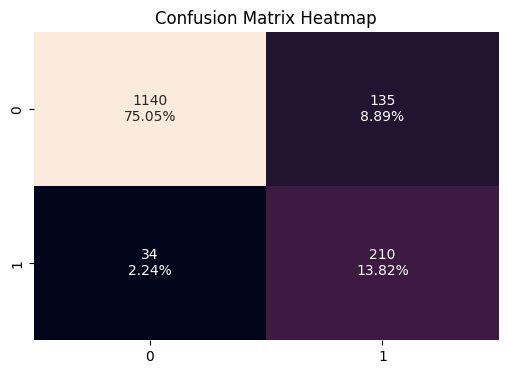


True Positives (TP): 210
False Positives (FP): 135
True Negatives (TN): 1140
False Negatives (FN): 34


In [116]:
plot_confusion_matrix(gbc_tuned_oversample, x_validation_data, y_validation_data)

Gradient Boosting Undersampled

In [117]:
start_time = start_timer()
gbc_undersample = GradientBoostingClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=gbc_undersample,
    param_distributions=DECISION_TREE_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
    )

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_undersample, y_training_undersample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(75), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=42)} with CV score=0.9256707620852952:
Run Time: 0m 44s 528ms


In [118]:
# Tuned Gradiant Boosting
gbc_tuned_undersample = GradientBoostingClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT
)

gbc_tuned_undersample.fit(x_training_data, y_training_data)

GradientBoostingClassifier(max_features=0.5, n_estimators=20, random_state=42,
                           subsample=0.7)

In [119]:
# Checking GBC tuned model peformance
gbc_tuned_undersample_scores = model_performance_classification_sklearn(gbc_tuned_undersample, x_training_data, y_training_data)

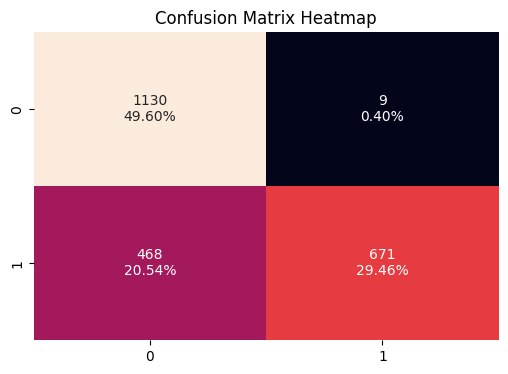


True Positives (TP): 671
False Positives (FP): 9
True Negatives (TN): 1130
False Negatives (FN): 468


In [120]:
plot_confusion_matrix(gbc_tuned_undersample, x_training_undersample, y_training_undersample)

In [121]:
gbc_tuned_undersample_validation_scores = model_performance_classification_sklearn(gbc_tuned_undersample, x_validation_data, y_validation_data)

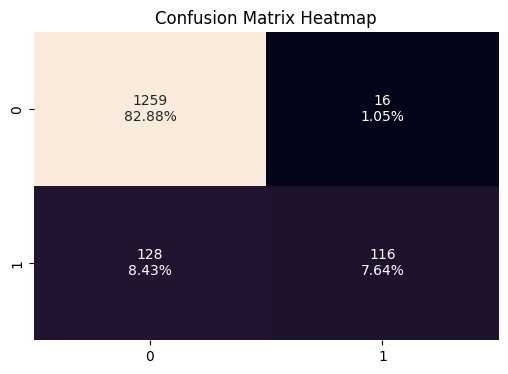


True Positives (TP): 116
False Positives (FP): 16
True Negatives (TN): 1259
False Negatives (FN): 128


In [122]:
plot_confusion_matrix(gbc_tuned_undersample, x_validation_data, y_validation_data)

ADA Boost Original

In [123]:
# Define parameters
ADA_BOOST_PARAMS = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [
        # Changed 'base_estimator' to 'estimator'
        DecisionTreeClassifier(max_depth=2, random_state=SEED),
        DecisionTreeClassifier(max_depth=3, random_state=SEED),
    ],
}

In [124]:
# AdaBoost
start_time = start_timer()
ada = AdaBoostClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=ada,
    param_distributions=ADA_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_data, y_training_data)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'n_estimators': np.int64(100), 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=42)} with CV score=0.9304365860052999:
Run Time: 1m 14s 564ms


In [125]:
ada_tuned = AdaBoostClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  estimator=DecisionTreeClassifier(max_depth=2, random_state=SEED),
)

ada_tuned.fit(x_training_data, y_training_data)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=42),
                   learning_rate=0.1, n_estimators=20, random_state=42)

In [126]:
# Checking ADA tuned model peformance
ada_tuned_scores = model_performance_classification_sklearn(ada_tuned, x_training_data, y_training_data)

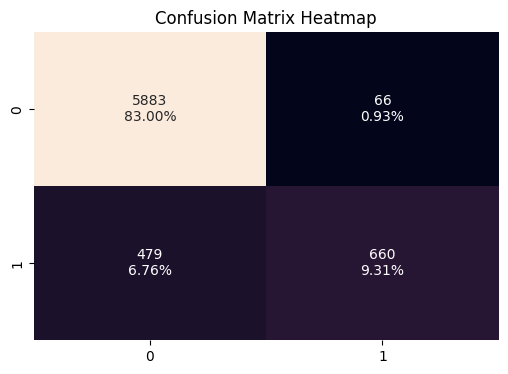


True Positives (TP): 660
False Positives (FP): 66
True Negatives (TN): 5883
False Negatives (FN): 479


In [127]:
plot_confusion_matrix(ada_tuned, x_training_data, y_training_data)

In [128]:
ada_tuned_validation_scores = model_performance_classification_sklearn(ada_tuned, x_validation_data, y_validation_data)

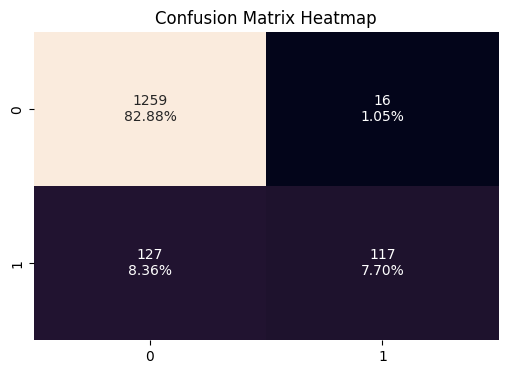


True Positives (TP): 117
False Positives (FP): 16
True Negatives (TN): 1259
False Negatives (FN): 127


In [129]:
plot_confusion_matrix(ada_tuned, x_validation_data, y_validation_data)

ADABoost Oversampled

In [130]:
# AdaBoost
start_time = start_timer()
ada_oversample = AdaBoostClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=ada_oversample,
    param_distributions=ADA_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_oversample, y_training_oversample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'n_estimators': np.int64(75), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=42)} with CV score=0.9308820491374785:
Run Time: 2m 8s 569ms


In [131]:
ada_tuned_oversample = AdaBoostClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  estimator=DecisionTreeClassifier(max_depth=2, random_state=SEED),
)

ada_tuned_oversample.fit(x_training_oversample, y_training_oversample)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=42),
                   learning_rate=0.1, n_estimators=20, random_state=42)

In [132]:
# Checking ADA (oversampled) tuned model peformance
ada_tuned_oversample_scores = model_performance_classification_sklearn(ada_tuned_oversample, x_training_oversample, y_training_oversample)

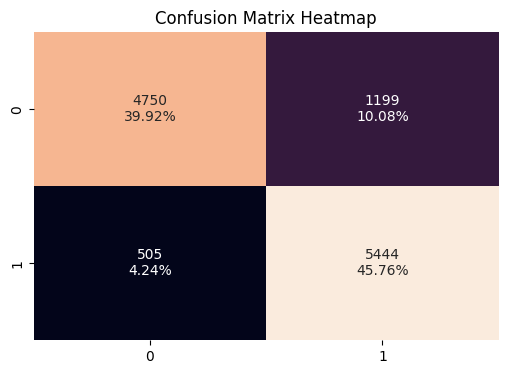


True Positives (TP): 5444
False Positives (FP): 1199
True Negatives (TN): 4750
False Negatives (FN): 505


In [133]:
plot_confusion_matrix(ada_tuned_oversample, x_training_oversample, y_training_oversample)

In [134]:
ada_tuned_oversample_validation_scores = model_performance_classification_sklearn(ada_tuned_oversample, x_validation_data, y_validation_data)

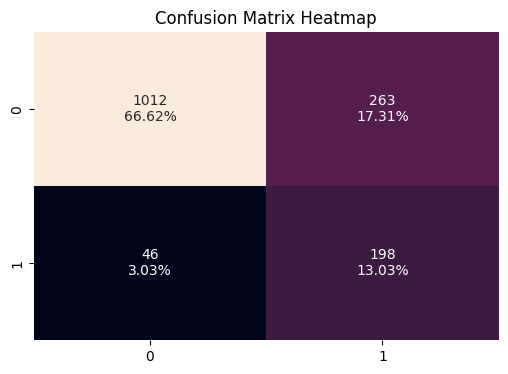


True Positives (TP): 198
False Positives (FP): 263
True Negatives (TN): 1012
False Negatives (FN): 46


In [135]:
plot_confusion_matrix(ada_tuned_oversample, x_validation_data, y_validation_data)

ADABoost Undersampled

In [136]:
# AdaBoost
start_time = start_timer()
ada_undersample = AdaBoostClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=ada_undersample,
    param_distributions=ADA_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_undersample, y_training_undersample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'n_estimators': np.int64(75), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=42)} with CV score=0.9336203337462153:
Run Time: 0m 30s 33ms


In [137]:
ada_tuned_undersample = AdaBoostClassifier(
  random_state=SEED,
  n_estimators=TUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  estimator=DecisionTreeClassifier(max_depth=2, random_state=SEED),
)

ada_tuned_undersample.fit(x_training_undersample, y_training_undersample)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=42),
                   learning_rate=0.1, n_estimators=20, random_state=42)

In [138]:
# Checking ADA tuned model peformance
ada_tuned_undersample_scores = model_performance_classification_sklearn(ada_tuned_undersample, x_training_undersample, y_training_undersample)

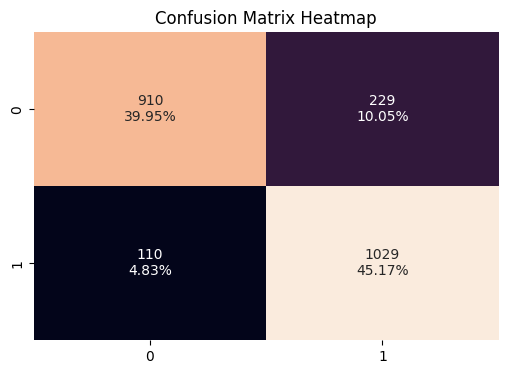


True Positives (TP): 1029
False Positives (FP): 229
True Negatives (TN): 910
False Negatives (FN): 110


In [139]:
plot_confusion_matrix(ada_tuned_undersample, x_training_undersample, y_training_undersample)

In [140]:
ada_tuned_undersample_validation_scores = model_performance_classification_sklearn(ada_tuned_undersample, x_validation_data, y_validation_data)

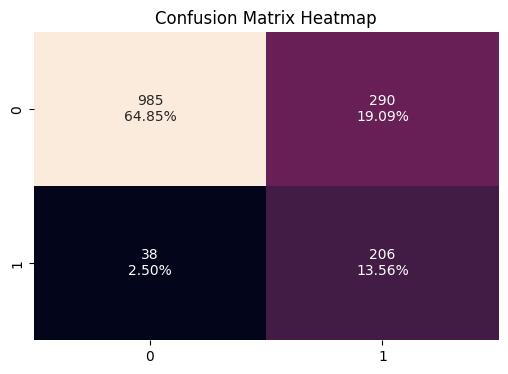


True Positives (TP): 206
False Positives (FP): 290
True Negatives (TN): 985
False Negatives (FN): 38


In [141]:
plot_confusion_matrix(ada_tuned_undersample, x_validation_data, y_validation_data)

XGB Boost Original

In [142]:
# Params
XGB_BOOST_PARAMS = {
    'n_estimators':np.arange(50, 110, 25),
    'scale_pos_weight':[1, 2, 5],
    'learning_rate':[0.01, 0.1, 0.05],
    'gamma':[1, 3],
    'subsample':[0.7, 0.9]
}

In [143]:
# XGB Boost (Optional)
start_time = start_timer()
xgb = XGBClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=XGB_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
    )

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_data, y_training_data)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': np.int64(100), 'learning_rate': 0.01, 'gamma': 3} with CV score=0.9505694276012612:
Run Time: 0m 13s 462ms


In [144]:
xgb_tuned = XGBClassifier(
  random_state=SEED,
  n_estimators=UNTUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT,
  gamma=MIN_TREE_SPLIT
)

xgb_tuned.fit(x_training_data, y_training_data)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_features=0.5, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=50, n_jobs=None, ...)

In [145]:
# Checking XGB tuned model peformance
xgb_tuned_scores = model_performance_classification_sklearn(xgb_tuned, x_training_data, y_training_data)

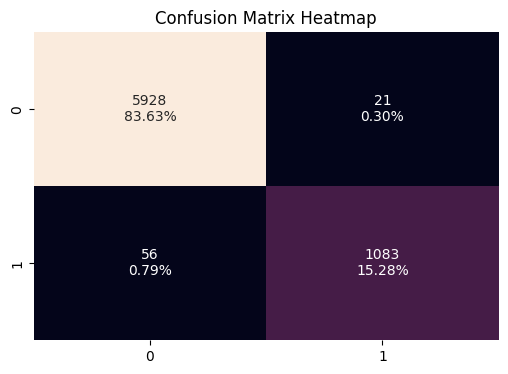


True Positives (TP): 1083
False Positives (FP): 21
True Negatives (TN): 5928
False Negatives (FN): 56


In [146]:
plot_confusion_matrix(xgb_tuned, x_training_data, y_training_data)

In [147]:
xgb_tuned_validation_scores = model_performance_classification_sklearn(xgb_tuned, x_validation_data, y_validation_data)

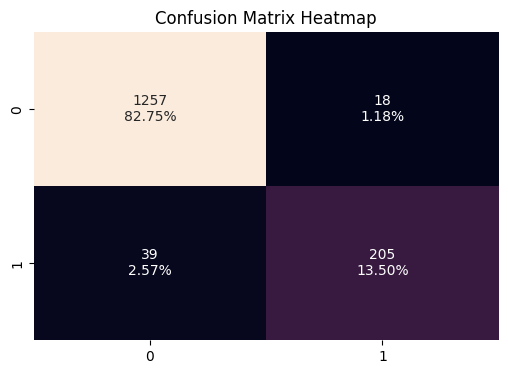


True Positives (TP): 205
False Positives (FP): 18
True Negatives (TN): 1257
False Negatives (FN): 39


In [148]:
plot_confusion_matrix(xgb_tuned, x_validation_data, y_validation_data)

XGBoost Oversampled

In [149]:
start_time = start_timer()
xgb_oversample = XGBClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=xgb_oversample,
    param_distributions=XGB_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
    )

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_oversample, y_training_oversample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': np.int64(100), 'learning_rate': 0.1, 'gamma': 1} with CV score=0.9662237762393276:
Run Time: 0m 15s 962ms


In [150]:
# XGB Tuned Oversample
xgb_tuned_oversample = XGBClassifier(
  random_state=SEED,
  n_estimators=UNTUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT,
  gamma=MIN_TREE_SPLIT
)

xgb_tuned_oversample.fit(x_training_oversample, y_training_oversample)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_features=0.5, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=50, n_jobs=None, ...)

In [151]:
# Checking XGB tuned model peformance
xgb_tuned_oversample_scores = model_performance_classification_sklearn(xgb_tuned_oversample, x_training_oversample, y_training_oversample)

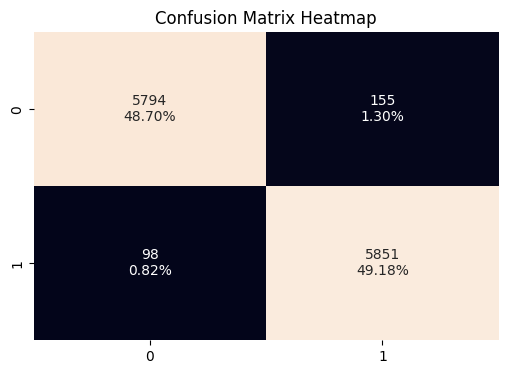


True Positives (TP): 5851
False Positives (FP): 155
True Negatives (TN): 5794
False Negatives (FN): 98


In [152]:
plot_confusion_matrix(xgb_tuned_oversample, x_training_oversample, y_training_oversample)

In [153]:
xgb_tuned_oversample_validation_scores = model_performance_classification_sklearn(xgb_tuned_oversample, x_validation_data, y_validation_data)

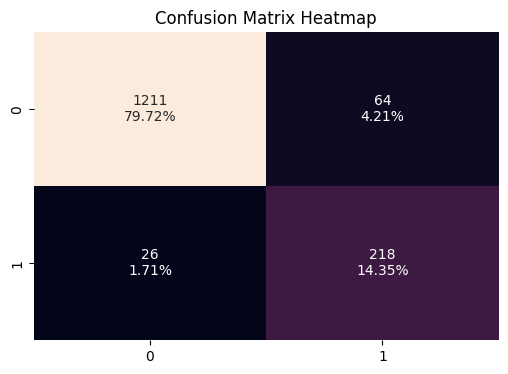


True Positives (TP): 218
False Positives (FP): 64
True Negatives (TN): 1211
False Negatives (FN): 26


In [154]:
plot_confusion_matrix(xgb_tuned_oversample, x_validation_data, y_validation_data)

XGB Boost Undersampled

In [155]:
start_time = start_timer()
xgb_undersample = XGBClassifier(random_state=SEED)

scorer = make_scorer(precision_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=xgb_undersample,
    param_distributions=XGB_BOOST_PARAMS, #param_grid,
    n_iter=PARAM_DISTR_CNT,
    n_jobs=MAX_PROC_THREADS,
    scoring=scorer,
    cv=CV_FOLDS,
    random_state=SEED
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(x_training_undersample, y_training_undersample)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))
show_timer(start_time)

Best parameters are {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': np.int64(100), 'learning_rate': 0.1, 'gamma': 1} with CV score=0.9490937531293078:
Run Time: 0m 8s 943ms


In [156]:
xgb_tuned_undersample = XGBClassifier(
  random_state=SEED,
  n_estimators=UNTUNED_ESTIMATOR_CNT,
  learning_rate=TUNED_LEARNING_RATE,
  subsample=SUB_SAMPLE_SIZE,
  max_features=FEATURES_SPLIT_PCT,
  gamma=MIN_TREE_SPLIT
)

xgb_tuned_undersample.fit(x_training_undersample, y_training_undersample)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_features=0.5, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=50, n_jobs=None, ...)

In [157]:
xgb_tuned_undersample_scores = model_performance_classification_sklearn(xgb_tuned_undersample, x_training_undersample, y_training_undersample)

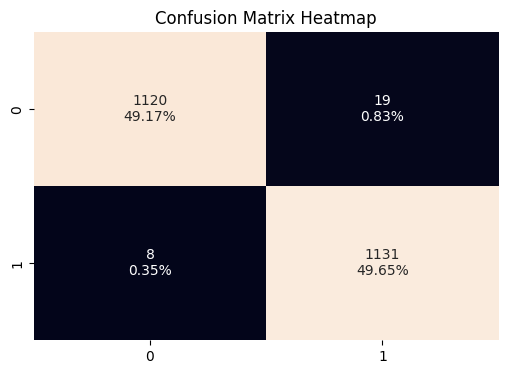


True Positives (TP): 1131
False Positives (FP): 19
True Negatives (TN): 1120
False Negatives (FN): 8


In [158]:
plot_confusion_matrix(xgb_tuned_undersample, x_training_undersample, y_training_undersample)

In [159]:
xgb_tuned_undersample_validation_scores = model_performance_classification_sklearn(xgb_tuned_undersample, x_validation_data, y_validation_data)

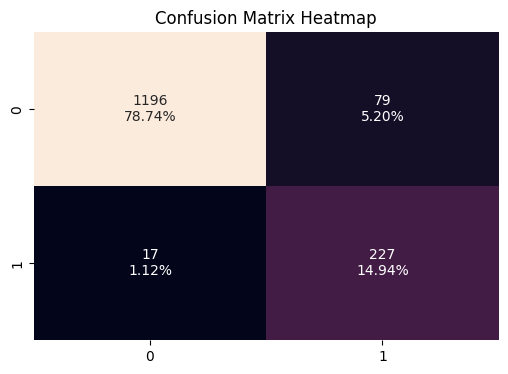


True Positives (TP): 227
False Positives (FP): 79
True Negatives (TN): 1196
False Negatives (FN): 17


In [160]:
plot_confusion_matrix(xgb_tuned_undersample, x_validation_data, y_validation_data)

#### Sample tuning method for Decision tree with oversampled data

**Note:** *Undersampled data is grouped by grid.*

#### Sample tuning method for Decision tree with undersampled data

**Note:** *Oversampled data is grouped by grid.*

## Model Comparison and Final Model Selection

In [161]:
# Training Comparison
training_models = pd.concat([
  gbc_tuned_scores.T,
  gbc_tuned_oversample_scores.T,
  gbc_tuned_undersample_scores.T,
  ada_tuned_scores.T,
  ada_tuned_oversample_scores.T,
  ada_tuned_undersample_scores.T,
  xgb_tuned_scores.T,
  xgb_tuned_oversample_scores.T,
  xgb_tuned_undersample_scores.T,
], axis=1)


training_models.columns = [
  'Gradient Boosting Original',
  'Gradient Boosting Oversampled',
  'Gradient Boosting Undersampled',
  'AdaBoost Original',
  'AdaBoost Oversampled',
  'AdaBoost Undersampled',
  'XGBoost Original',
  'XGBoost Oversampled',
  'XGBoost Undersampled'
]

# Empty list to store all the models
# Appending models into the list
show_banner('Training Performance Comparison')
training_models

# =================================
#  Training Performance Comparison
# =================================



,Gradient Boosting Original,Gradient Boosting Oversampled,Gradient Boosting Undersampled,AdaBoost Original,AdaBoost Oversampled,AdaBoost Undersampled,XGBoost Original,XGBoost Oversampled,XGBoost Undersampled
Accuracy,0.926,0.926,0.926,0.923,0.857,0.851,0.989,0.979,0.988
Recall,0.589,0.947,0.589,0.579,0.915,0.903,0.951,0.984,0.993
Precision,0.918,0.908,0.918,0.909,0.820,0.818,0.981,0.974,0.983
F1,0.718,0.927,0.718,0.708,0.865,0.859,0.966,0.979,0.988


In [162]:
# Validation Comparison
validation_models = pd.concat([
  gbc_tuned_validation_scores.T,
  gbc_tuned_oversample_validation_scores.T,
  gbc_tuned_undersample_validation_scores.T,
  ada_tuned_validation_scores.T,
  ada_tuned_oversample_validation_scores.T,
  ada_tuned_undersample_validation_scores.T,
  xgb_tuned_validation_scores.T,
  xgb_tuned_oversample_validation_scores.T,
  xgb_tuned_undersample_validation_scores.T,
], axis=1)


validation_models.columns = [
  'Gradient Boosting Original Value',
  'Gradient Boosting Oversampled Value',
  'Gradient Boosting Undersampled Value',
  'AdaBoost Original Value',
  'AdaBoost Oversampled Value',
  'AdaBoost Undersampled Value',
  'XGBoost Original Value',
  'XGBoost Oversampled Value',
  'XGBoost Undersampled Value'
]

# Empty list to store all the models
# Appending models into the list
show_banner('Training Performance Comparison')
validation_models

# =================================
#  Training Performance Comparison
# =================================



,Gradient Boosting Original Value,Gradient Boosting Oversampled Value,Gradient Boosting Undersampled Value,AdaBoost Original Value,AdaBoost Oversampled Value,AdaBoost Undersampled Value,XGBoost Original Value,XGBoost Oversampled Value,XGBoost Undersampled Value
Accuracy,0.905,0.889,0.905,0.906,0.797,0.784,0.962,0.941,0.937
Recall,0.475,0.861,0.475,0.480,0.811,0.844,0.840,0.893,0.930
Precision,0.879,0.609,0.879,0.880,0.430,0.415,0.919,0.773,0.742
F1,0.617,0.713,0.617,0.621,0.562,0.557,0.878,0.829,0.825


### Test set final performance

In [163]:
# Top 3 models to test for comparison.
xgb_undersample_scores_model = model_performance_classification_sklearn(xgb_tuned_undersample, x_testing_data, y_testing_data)
xgb_oversample_scores_model = model_performance_classification_sklearn(xgb_tuned_oversample, x_testing_data, y_testing_data)
xgb_tuned_scores_model = model_performance_classification_sklearn(xgb_tuned, x_testing_data, y_testing_data)

In [220]:
# =========================
#  TOP 3 XGBOOST MODELS
# =========================

xgb_models = [
    xgb_tuned_undersample,
    xgb_tuned_oversample,
    xgb_tuned
]

xgb_comparison_models = pd.concat([
    xgb_undersample_scores_model.T,
    xgb_oversample_scores_model.T,
    xgb_tuned_scores_model.T],
    axis=1
    )

xgb_comparison_models.columns = [
    'XGBoost Undersampled',
    'XGBoost Oversampled',
    'XGBoost Tuned'
    ]

show_banner('XGBoost Performance Comparison')
xgb_comparison_models

# ================================
#  XGBoost Performance Comparison
# ================================



,XGBoost Undersampled,XGBoost Oversampled,XGBoost Tuned
Accuracy,0.942,0.945,0.964
Recall,0.943,0.906,0.865
Precision,0.757,0.784,0.906
F1,0.839,0.840,0.885


In [221]:
# Final model (highest score)
# top_model was previously assigned a DataFrame, we need to reassign it to the actual model
top_model = pick_top_model(xgb_comparison_models, xgb_models)  # Assuming xgb_tuned_oversample is your desired model

# ===========
#  TOP MODEL
# ===========

 XGBoost Tuned


Accuracy    0.964
Recall      0.865
Precision   0.906
F1          0.885
Name: XGBoost Tuned, dtype: float64


In [222]:
# Now we can call model_performance_classification_sklearn
model_performance_classification_sklearn(top_model, x_testing_data, y_testing_data)

,Accuracy,Recall,Precision,F1
0,0.964,0.865,0.906,0.885


# =========================
#  Final Model Performance
# =========================



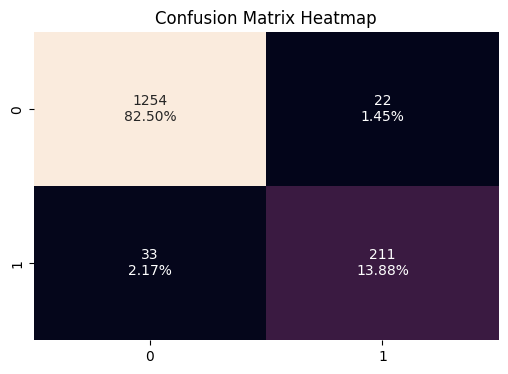


True Positives (TP): 211
False Positives (FP): 22
True Negatives (TN): 1254
False Negatives (FN): 33


In [223]:
# Perform Final Testing:
show_banner('Final Model Performance')
plot_confusion_matrix(top_model, x_testing_data, y_testing_data)

# Business Insights and Conclusions

1. True Positives (TP): This is the number of positive instances that were correctly predicted by the model. In your case, the model correctly predicted 211 instances as positive.

2. False Positives (FP): These are the negative instances that were incorrectly predicted as positive by the model. Here, 22 instances were incorrectly classified as positive.

3. True Negatives (TN): This refers to the number of negative instances that were correctly predicted by the model. For your data, 1254 negative instances were correctly identified.

4. False Negatives (FN): These are the positive instances that were incorrectly predicted as negative. In your statistics, 33 positive instances were missed by the model and classified as negative.

5. False positive must be diminished or minimized to have an accurate depiction of the model.

6. Gradient Boosting has the least amount of instances of negatives or positives, followed by AdaBoost then XGBoost.

7.  Attrited customers are most likely to be contacted to become customers again.

8. The most important factors when determing customer attrition are: Total Transaction Amount, Total Change Quarter 4 to Quarter 1 (revolving), Total Revolving Balance, Credit Limit.

9.  Factors that matter the lease are card category, gender, marital status, number of dependents and total relationship count.

10.  The longer a customer has been inactive the least likely they will return as a customer.

11. Income category does not matter as much as one would think pertaining to attrition.

12. Average open to buy and average utilization rate have the least correlation of any two attributes.

13.  The best way to keep customers is engagement.  Increase contact as soon as inactivity stops.  Also, sign them up for more services (increase relationship account) to discourage them from leaving.  Keep the fees coming in.

14. Last but not least we have an F1 Score of 88.5% for XBG Tuned Classifier Model.



***

# **END OF PROGRAM**